In [243]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [244]:
cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

In [245]:
task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

device_key = "Device"
device_proxy = "P"
device_controller = "C"

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

In [246]:
unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'
imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

In [247]:
baseline_ms = 30_000

extrema_quantile = 0.25

In [248]:
def remove_timeseries_outliers(df, key):
    df = df.dropna(subset = key)
    return df[np.abs(stats.zscore(df[key])) < 3] if key != hr_key else df

def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    if e == cube:
        return df[unity_unix_key].min()
    else:
        first_load = df[(df["collision_or_load_count"] == 1)]
        return first_load[unity_unix_key].min()

def task_end(df, e):
    if e == cube:
        return df[unity_unix_key].max()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    imot_pre_task = trim_df(imot_synced, task_start_ts - baseline_ms, task_start_ts)

    min_hr = remove_timeseries_outliers(imot_pre_task, hr_key)[hr_key].quantile(extrema_quantile)
    max_gsr_res = remove_timeseries_outliers(imot_pre_task, gsr_res_key)[gsr_res_key].quantile(1-extrema_quantile)
    min_gsr_con = remove_timeseries_outliers(imot_pre_task, gsr_con_key)[gsr_con_key].quantile(extrema_quantile)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        "min_hr": min_hr,
        "max_gsr_res": max_gsr_res,
        "min_gsr_con": min_gsr_con
    }

def get_experiment(p, e):

    condition_data = list(map(lambda x: get_condition(p, e, x), conditions))

    min_hr = np.min(list(map(lambda x: x["min_hr"], condition_data)))
    max_gsr_res = np.max(list(map(lambda x: x["max_gsr_res"], condition_data)))
    min_gsr_con = np.min(list(map(lambda x: x["min_gsr_con"], condition_data)))

    return {
            c_0: condition_data[0],
            c_1: condition_data[1],
            c_2: condition_data[2],
            p_0: condition_data[3],
            p_1: condition_data[4],
            p_2: condition_data[5],
            "min_hr": min_hr,
            "max_gsr_res": max_gsr_res,
            "min_gsr_con": min_gsr_con
    }
def get_participant(p):
    return {
        cube: get_experiment(p, cube),
        shovel: get_experiment(p, shovel),
        subject_key: p
    }

In [249]:
data = list(map(lambda x: get_participant(x), cohort))

In [250]:
print(data[0][subject_key])
print(data[len(data)-1][subject_key])
data[0][shovel][c_0][unity].head(3)

1_AlDe
42_StSp


,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,hmd_z,ee_x,ee_y,ee_z,shovel_loaded_state,cube_max_target_reached,grab_count,collision_or_load_count,unix_ms,delta_ms
0,6/17/2025 12:47:46 PM,1750157266336,Right,0.013479,0.082617,0.009835,-0.026263,0.161040,0.275415,0.013534,...,0.109002,-0.000339,0.069995,0.740010,False,0,1,0,1750157266336,-7097
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,0.108624,-0.109571,0.213849,0.729117,False,0,1,0,1750157266350,-7083
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,0.107817,-0.109463,0.209042,0.729566,False,0,1,0,1750157266379,-7054


In [251]:
def pre_post_delta(p, key):
    end = p[end_ts]

    end_df = trim_df(p[imot], min_ts = end, max_ts = end + baseline_ms)
    end_df = remove_timeseries_outliers(end_df, key)

    baseline = p["min_hr"] if key == hr_key else (p["max_gsr_res"] if key == gsr_res_key else (p["min_gsr_con"] if key == gsr_con_key else 0))

    return end_df[key].quantile(1-extrema_quantile) - baseline

def normalized_auc(p, key):
    start = p[start_ts]
    end = p[end_ts]
    duration = start-end

    task_df = trim_df(p[imot], min_ts = start, max_ts = end)
    task_df = remove_timeseries_outliers(task_df, key)

    baseline = p["min_hr"] if key == hr_key else (p["max_gsr_res"] if key == gsr_res_key else (p["min_gsr_con"] if key == gsr_con_key else 0))

    return metrics.auc(task_df[unified_delta_key].apply(lambda x: x / duration), task_df[key].apply(lambda x: x - baseline))

In [252]:
tuple_value_key = "v"
tuple_subject_key = "p"

def find_outliers(tuples, m=3):
    values = list(map(lambda x: x[tuple_value_key], tuples))
    mean = np.mean(values)
    std = np.std(values)

    outliers = []
    for i in tuples:
        value = i[tuple_value_key]
        if np.abs(value - mean) > m * std:
            outliers.append(i)

    return outliers

def agg_values(data, single_func, e, c):
    participant_values = list(map(lambda x: {tuple_value_key: single_func(x[e][c]), tuple_subject_key: x[subject_key]}, data))
    return participant_values

def get_condition_values(data, single_func, e, remove_outliers):
    complete_values =  []
    outliers_set = set([])

    for c in conditions:
        condition_values = agg_values(data, single_func, e, c)
        complete_values.append(condition_values)

        if remove_outliers:
            cond_outliers = find_outliers(condition_values)
            for i in cond_outliers:
                print("[" + e + "] " + c + " subject " + i[tuple_subject_key] + " is outlier")
                outliers_set.add(i[tuple_subject_key])

    if remove_outliers:
        for outlier in outliers_set:
            print("[" + e + "] dropping subject " + outlier)

        #Filter out outliers from ALL conditions afterwards
        filtered_values = []
        for condition_values in complete_values:
            filtered_condition_values = list(filter(lambda x: x[tuple_subject_key] not in outliers_set, condition_values))
            filtered_values.append(filtered_condition_values)

        return filtered_values

    else:
        return complete_values

In [253]:
significance_key = "Significance"
aov_key = "aov"
pairwise_key = "pairwise"
eff_size_key = "ng2"

def get_significant_entries(df):
    return df[df[significance_key] == "✅"]

def get_semi_significant_entries(df):
    return df[df[significance_key] != "❌"]

def two_way_repeated_measures_anova_core(df, value_key):
    aov = pg.rm_anova(
        dv=value_key,
        within=[device_key, scaling_key],
        subject=subject_key,
        data=df,
        detailed=True
    )

    p_key = "p-GG-corr"
    aov[significance_key] = aov.apply(lambda x: "✅" if x[p_key] < 0.05 else ("🟨"  if x[p_key] < 0.1 else "❌"), axis=1)

    display(aov)

    pairwise = pg.pairwise_tests(
    dv=value_key,
    within=[device_key, scaling_key],
    subject=subject_key,
    data=df,
    padjust='holm'
    )

    p_unc = "p-unc"
    p_corr = "p-corr"
    pairwise[significance_key] = pairwise.apply(lambda x:
        "✅" if
            (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    semi_significant_pairwise = pairwise[pairwise[significance_key] != "❌"]
    if(semi_significant_pairwise.shape[0] > 0):
        display(semi_significant_pairwise)

    return {
        aov_key: aov,
        pairwise_key: pairwise
    }

def two_way_repeated_measures_anova(condition_values):
    value_key = 'target_var'
    data =  {subject_key: [], device_key: [], scaling_key: [], value_key: [], condition_key: []}
    df = pd.DataFrame(data)

    for i in range(len(conditions)):
        n_values = len(condition_values[i])
        device = [conditions[i][0]] * n_values # Device is always the same for condition
        scaling = [conditions[i][1:]] * n_values # Scaling is always the same for condition
        cond = [conditions[i]] * n_values # Condition is always the same for condition

        values = list(map(lambda x: x[tuple_value_key], condition_values[i]))
        subjects = list(map(lambda x: x[tuple_subject_key], condition_values[i]))

        condition_data = {subject_key: subjects, device_key: device, scaling_key: scaling, value_key: values, condition_key: cond}
        condition_rows = pd.DataFrame(condition_data)
        df = pd.concat([df, condition_rows], ignore_index=True)

    return two_way_repeated_measures_anova_core(df, value_key)

In [254]:
#Adapted from https://stackoverflow.com/questions/11517986/indicating-the-statistically-significant-difference-in-bar-graph
def barplot_annotate_brackets(ax, num1, num2, data, x, y, offset, height, addtext='', color="black", fs=None, maxasterix=3):
    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = x[num1], y[num1]
    rx, ry = x[num2], y[num2]

    y = max(ly, ry) + offset

    barx = [lx, lx, rx, rx]
    bary = [y, y+height, y+height, y]
    mid = ((lx+rx)/2, y+height)

    ax.plot(barx, bary, c=color)

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    if addtext != "":
        text = text + " (" + addtext + ")"

    ax.text(*mid, text, color=color, **kwargs)

In [255]:
def get_confidence_interval(values):
    return 1.96 * np.std(values) / np.sqrt(len(values))

def plot_significance_brackets(ax, scale, barheights, pairwise):
    contrast = "Contrast"
    p_corr = "p-corr"
    p_unc = "p-unc"

    significant_pairwise = get_significant_entries(pairwise)

    n_bars = np.arange(len(conditions))

    offset_step = (scale[1] - scale[0]) / 10
    bracket_height = offset_step * 0.25
    fixed_heights =  [np.max(barheights) + bracket_height*2] * len(conditions)

    current_offset = 0

    individual = significant_pairwise[significant_pairwise[contrast] == device_x_scaling_key]
    individual_next = individual.loc[(individual['A'] != "0") | (individual['B'] != "2")]
    if individual_next.shape[0] > 0:
        for index, row in individual_next.iterrows():
            a = int(row["A"])
            b = int(row["B"])
            if row[device_key] == "P":
                a += 3
                b += 3
            barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
        current_offset += offset_step

    individual_spanning = individual.loc[(individual['A'] == "0") & (individual['B'] == "2")]
    if individual_spanning.shape[0] > 0:
        for index, row in individual_spanning.iterrows():
            a = int(row["A"])
            b = int(row["B"])
            if row[device_key] == "P":
                a += 3
                b += 3
            barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
        current_offset += offset_step

    scaling = significant_pairwise[significant_pairwise[contrast] == scaling_key]
    scaling_next = scaling.loc[(scaling['A'] != "0") | (scaling['B'] != "2")]
    if scaling_next.shape[0] > 0:
        for index, row in scaling_next.iterrows():
            a = int(row["A"])
            b = int(row["B"])
            text = row["A"] + "-" + row["B"]
            barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height, addtext=text, color="tab:orange")
        current_offset += offset_step

    scaling_spanning = scaling.loc[(scaling['A'] == "0") & (scaling['B'] == "2")]
    if scaling_spanning.shape[0] > 0:
        for index, row in scaling_spanning.iterrows():
            a = int(row["A"])
            b = int(row["B"])
            text = row["A"] + "-" + row["B"]
            barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height, addtext=text, color="tab:orange")
        current_offset += offset_step


    device = significant_pairwise[significant_pairwise[contrast] == device_key]
    if device.shape[0] > 0:
        for index, row in device.iterrows():
            barplot_annotate_brackets(ax, 0, 3, row[p_unc], n_bars, fixed_heights, offset=current_offset, height=bracket_height, addtext="C-P", color="tab:blue")
        current_offset += offset_step

    # Set axis limits to provided scale or max bracket height if higher
    ax.set_ylim([scale[0], np.max([fixed_heights[0]+current_offset, scale[1]])])


def plot_experiment(condition_values, e, title, ylabel, pairwise):
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('[' + e + '] ' + title)

    values = []
    for cond in condition_values:
        values.append(list(map(lambda x: x[tuple_value_key], cond)))

    means = list(map(lambda x: np.mean(x), values))
    confidence_values = list(map(get_confidence_interval, values))

    axs[0].bar(conditions, means, color=colors)
    axs[0].errorbar(conditions, means, yerr= confidence_values, fmt='none', capsize=6, color="black")
    axs[0].set_title('Mean (+CI)')
    #axs[0].set_yticks(range(scale[0], scale[1]+1))
    axs[0].set_ylabel(ylabel)

    barheights = []
    for i in range(len(conditions)):
        barheights.append(means[i] + confidence_values[i])

    plot_significance_brackets(axs[0], axs[0].get_ylim(), barheights, pairwise)

    n_bars = np.arange(len(conditions))

    axs[1].violinplot(values, showmeans=True)
    axs[1].set_title('Violin (+Mean)')
    axs[1].set_ylabel(ylabel)
    axs[1].set_xticks([y + 1 for y in n_bars], labels=conditions)

    axs[2].boxplot(values, tick_labels=conditions)
    axs[2].set_title('Boxplot')
    axs[2].set_ylabel(ylabel)

    fig.tight_layout()
    plt.show()

In [256]:
cube_aovs = []
shovel_aovs = []
aovs_dv_key = "key"
aovs_data_key = "data"

def try_add_aov_entry(new_entry, e):
    if e == cube and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in cube_aovs):
        cube_aovs.append(new_entry)
    elif e == shovel and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in shovel_aovs):
        shovel_aovs.append(new_entry)

def report_exeriment(data, func, e, title, ylabel, remove_outliers = True):
    print('\033[1m' + "------ " + "["+e+"] " + title + ":"  + " ------")
    values = get_condition_values(data, func, e, remove_outliers)
    anova_result = two_way_repeated_measures_anova(values)

    aov_entry = {
        aovs_dv_key: title,
        aovs_data_key: anova_result[aov_key]
    }
    try_add_aov_entry(aov_entry, e)

    plot_experiment(values, e, title, ylabel, anova_result[pairwise_key])

------ [Cube] Heart Rate Delta: ------
[Cube] C2 subject 22_ClSt is outlier
[Cube] dropping subject 22_ClSt


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,357.969766,1,40,357.969766,10.532887,0.002373,0.002373,0.025064,1.000000,✅
1,Scaling,23.049289,2,80,11.524644,0.239003,0.787973,0.776204,0.001653,0.947487,❌
2,Device * Scaling,106.119411,2,80,53.059705,1.153392,0.320756,0.316694,0.007564,0.889121,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.245441,40.0,two-sided,0.002373,NaN,NaN,14.095,-0.463298,✅


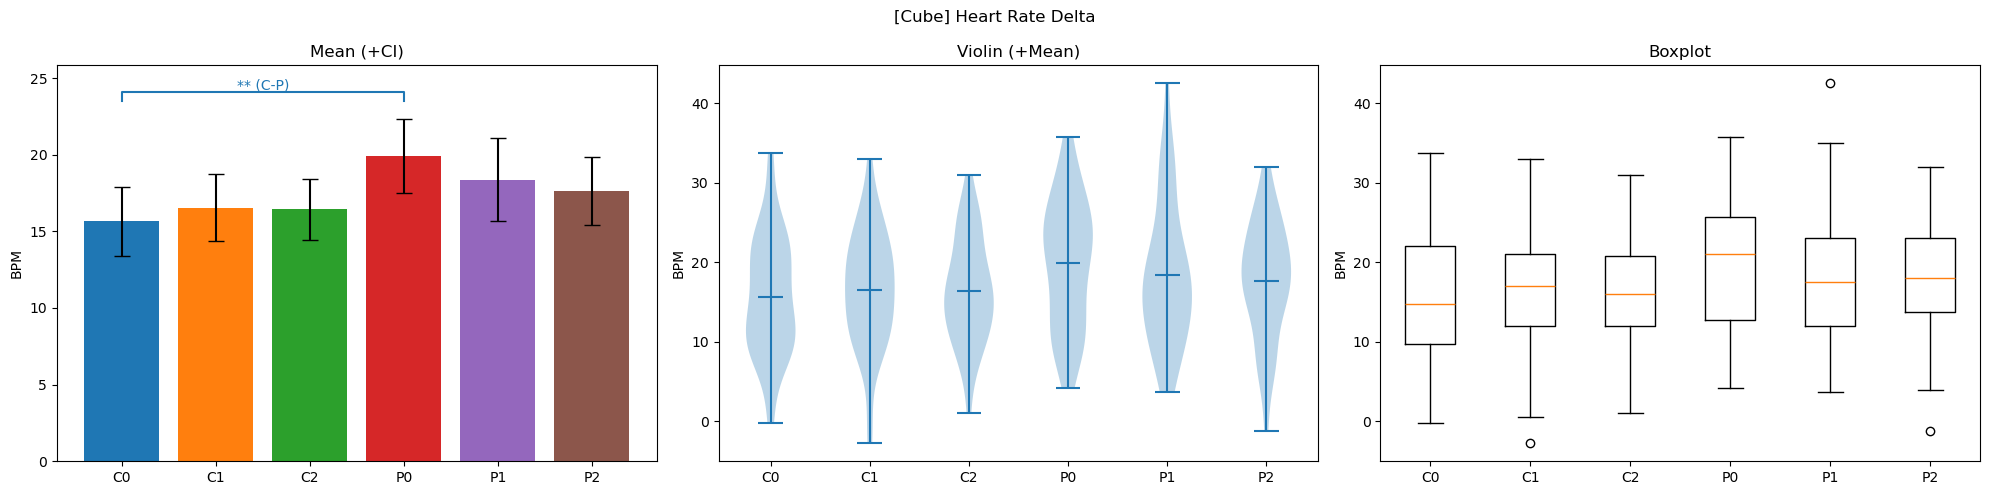

------ [Shovel] Heart Rate Delta: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,412.723214,1,41,412.723214,9.478558,0.003700,0.003700,0.029829,1.000000,✅
1,Scaling,195.031250,2,82,97.515625,3.216646,0.045198,0.045624,0.014321,0.991998,✅
2,Device * Scaling,64.209821,2,82,32.104911,1.283219,0.282650,0.282311,0.004761,0.971806,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.078727,41.0,two-sided,0.003700,NaN,NaN,9.471,-0.421959,✅
3,Scaling,-,1,2,True,True,2.349858,41.0,two-sided,0.023676,0.071028,holm,1.935,0.320834,🟨
9,Device * Scaling,P,1,2,True,True,2.929061,41.0,two-sided,0.005531,0.033183,holm,6.674,0.421011,✅


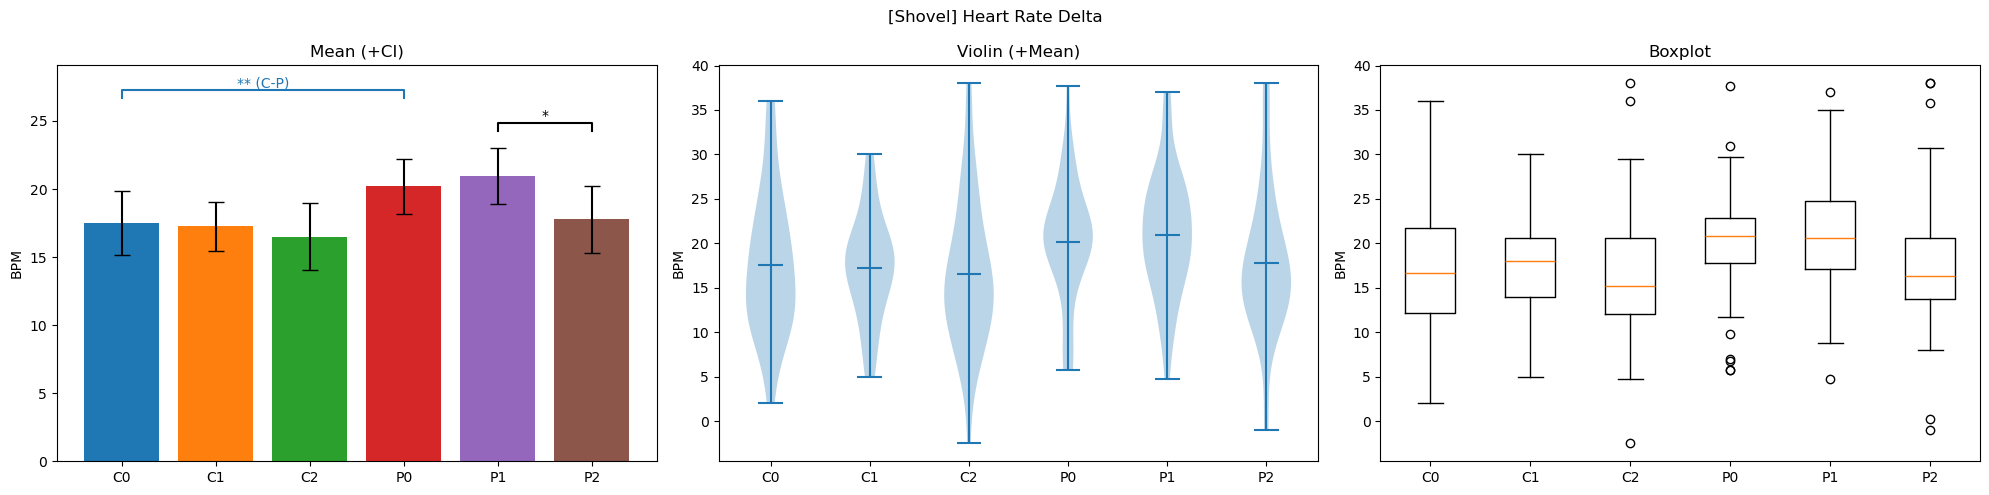

In [257]:
def hr_delta(p):
    return pre_post_delta(p, hr_key)

title = 'Heart Rate Delta'
ylabel = 'BPM'
report_exeriment(data, hr_delta, cube, title, ylabel)
report_exeriment(data, hr_delta, shovel, title, ylabel)

------ [Cube] Heart Rate AUC: ------
[Cube] C0 subject 31_GiDe is outlier
[Cube] P0 subject 12_ViDi is outlier
[Cube] dropping subject 12_ViDi
[Cube] dropping subject 31_GiDe


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.663795,1,39,5.663795,0.161184,0.690260,0.690260,0.000796,1.000000,❌
1,Scaling,102.943978,2,78,51.471989,2.425814,0.095049,0.098457,0.014272,0.944075,🟨
2,Device * Scaling,44.484316,2,78,22.242158,0.809129,0.448947,0.436215,0.006218,0.886688,❌


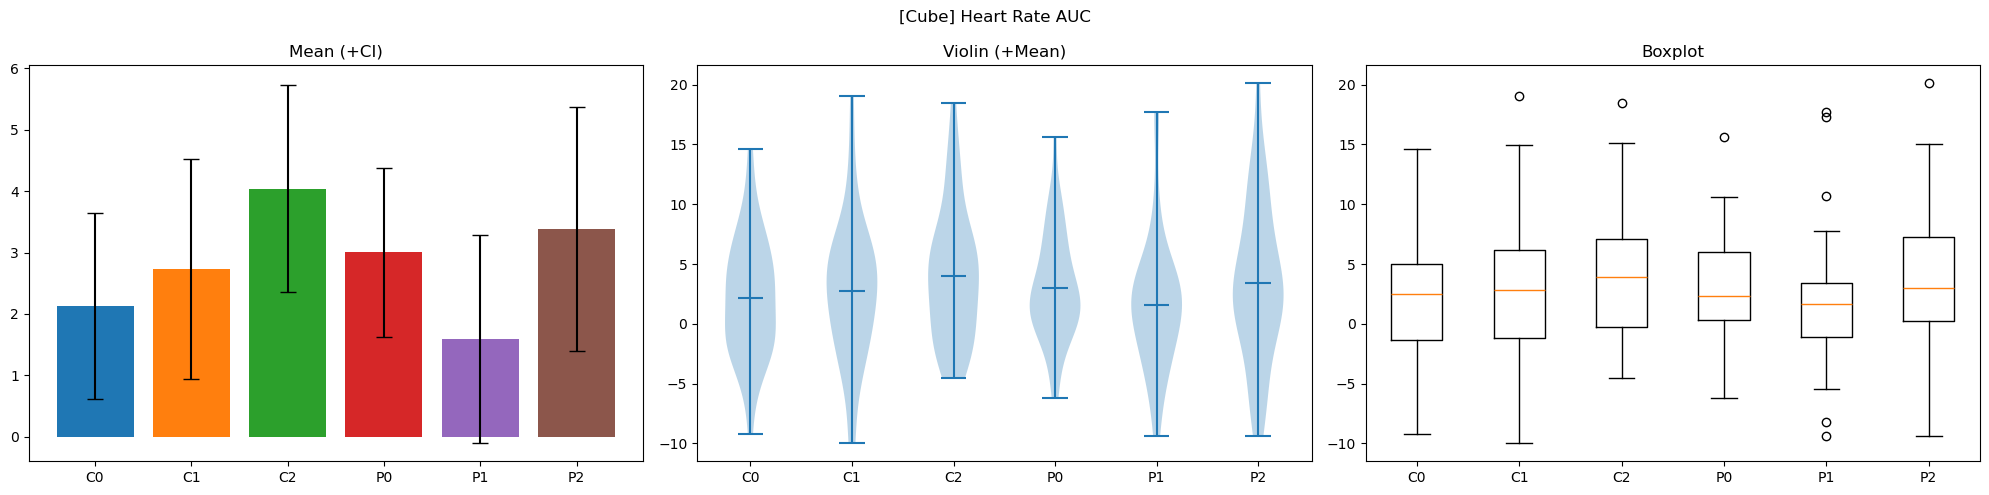

------ [Shovel] Heart Rate AUC: ------
[Shovel] P0 subject 42_StSp is outlier
[Shovel] dropping subject 42_StSp


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,195.572900,1,40,195.572900,5.626348,0.022592,0.022592,0.025345,1.000000,✅
1,Scaling,69.328457,2,80,34.664229,1.549963,0.218562,0.219276,0.009134,0.966164,❌
2,Device * Scaling,77.810616,2,80,38.905308,2.101950,0.128917,0.131691,0.010240,0.949595,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.371992,40.0,two-sided,0.022592,NaN,NaN,2.03,-0.419741,✅


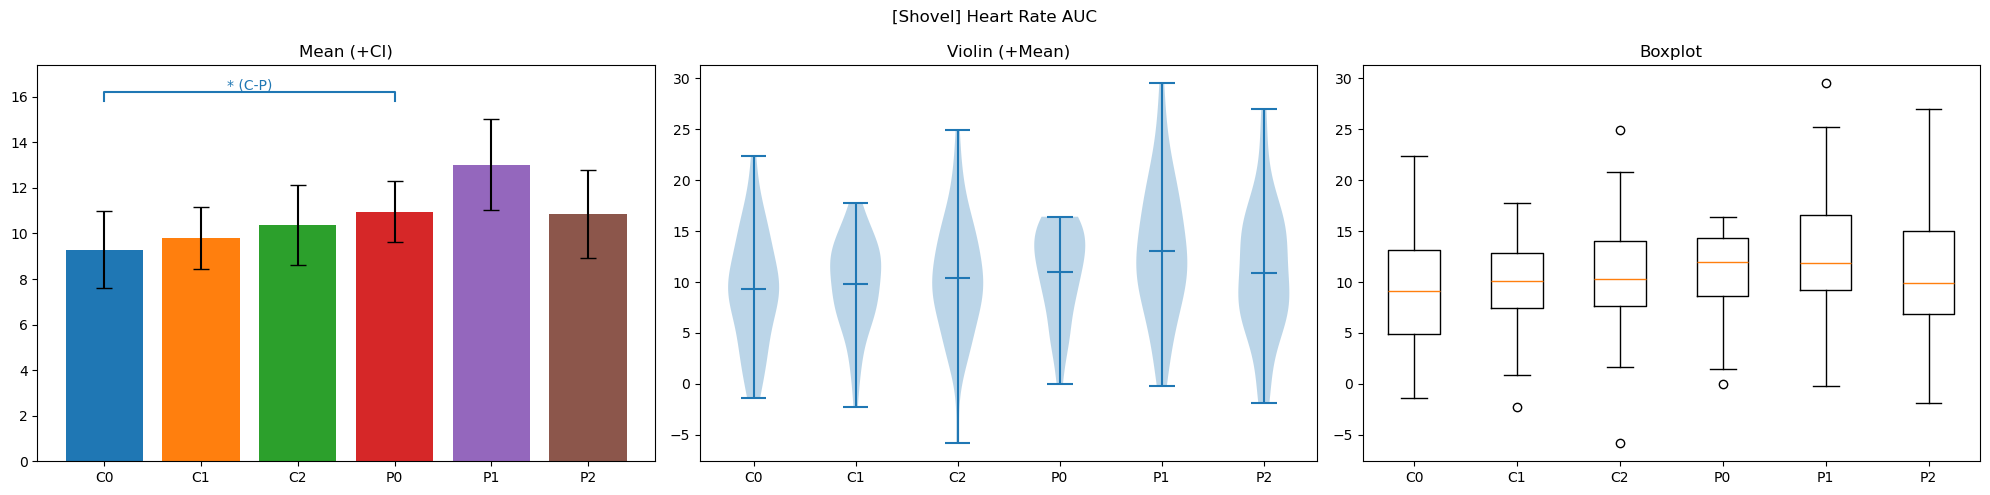

In [258]:
def hr_auc(p):
    return normalized_auc(p, hr_key)

title = 'Heart Rate AUC'
ylabel = ''
report_exeriment(data, hr_auc, cube, title, ylabel)
report_exeriment(data, hr_auc, shovel, title, ylabel)

------ [Cube] Skin Conductance Delta: ------
[Cube] C0 subject 11_SePe is outlier
[Cube] C1 subject 11_SePe is outlier
[Cube] C2 subject 11_SePe is outlier
[Cube] P0 subject 5_MaGo is outlier
[Cube] P1 subject 11_SePe is outlier
[Cube] P2 subject 3_JuRo is outlier
[Cube] dropping subject 3_JuRo
[Cube] dropping subject 5_MaGo
[Cube] dropping subject 11_SePe


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.877959,1,38,2.877959,5.450059,0.024953,0.024953,0.021531,1.000000,✅
1,Scaling,0.047618,2,76,0.023809,0.150091,0.860885,0.839223,0.000364,0.899283,❌
2,Device * Scaling,0.709172,2,76,0.354586,1.709355,0.187866,0.194018,0.005393,0.812606,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.334536,38.0,two-sided,0.024953,NaN,NaN,1.905,-0.326786,✅


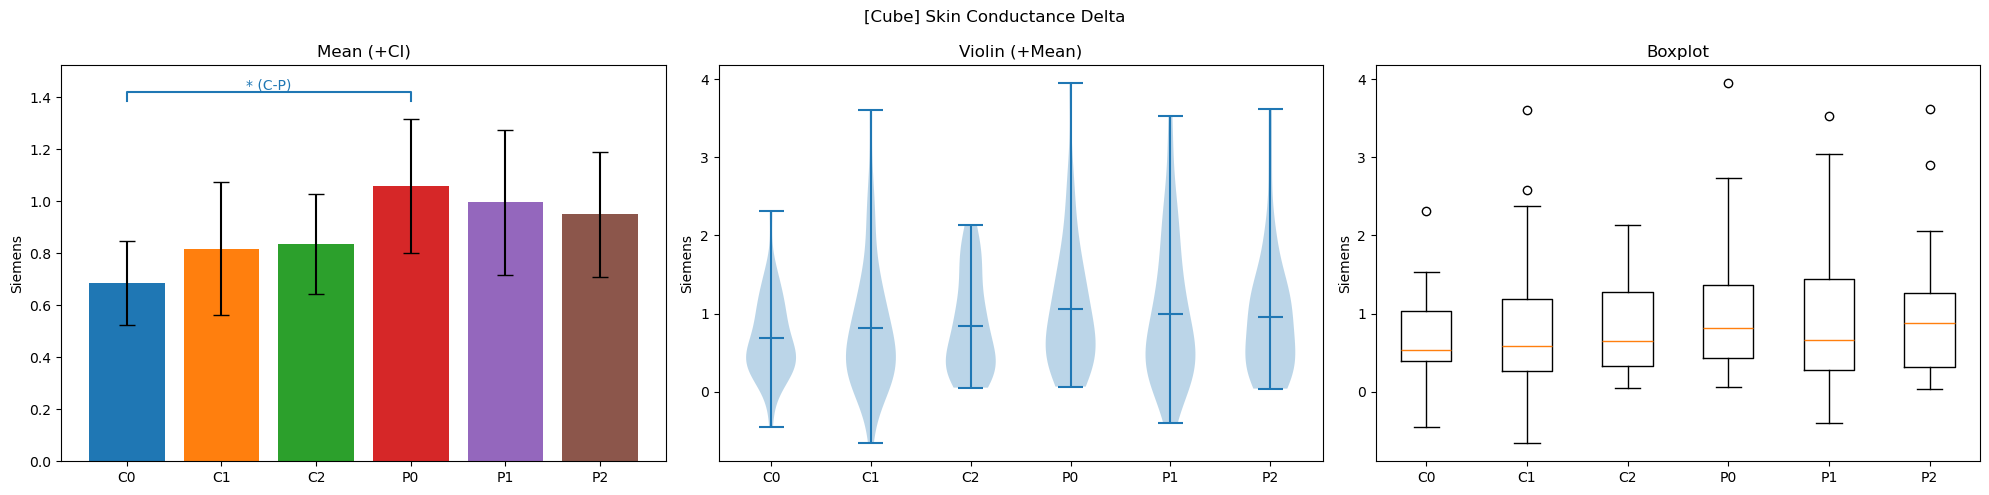

------ [Shovel] Skin Conductance Delta: ------
[Shovel] C0 subject 11_SePe is outlier
[Shovel] C1 subject 40_HeSe is outlier
[Shovel] C2 subject 11_SePe is outlier
[Shovel] P1 subject 40_HeSe is outlier
[Shovel] P2 subject 35_FlRu is outlier
[Shovel] dropping subject 40_HeSe
[Shovel] dropping subject 35_FlRu
[Shovel] dropping subject 11_SePe


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,18.579965,1,38,18.579965,24.281274,0.000017,0.000017,0.086678,1.000000,✅
1,Scaling,0.225752,2,76,0.112876,0.516202,0.598860,0.592214,0.001152,0.963562,❌
2,Device * Scaling,0.726545,2,76,0.363272,0.904928,0.408885,0.378400,0.003697,0.700655,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.927603,38.0,two-sided,0.000017,NaN,NaN,1262.874,-0.691052,✅


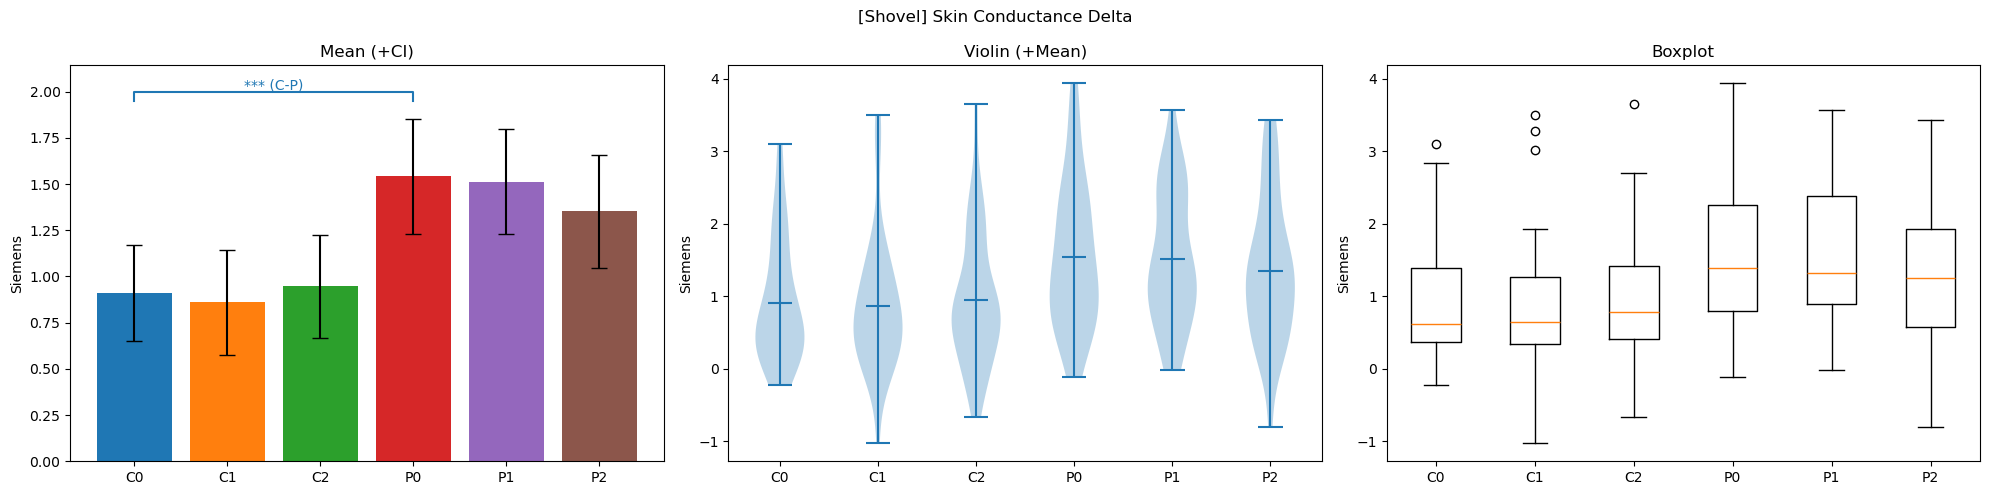

In [259]:
def gsr_con_delta(p):
    return pre_post_delta(p, gsr_con_key)

title = 'Skin Conductance Delta'
ylabel = 'Siemens'
report_exeriment(data, gsr_con_delta, cube, title, ylabel)
report_exeriment(data, gsr_con_delta, shovel, title, ylabel)

------ [Cube] Skin Conductance AUC: ------
[Cube] C0 subject 23_DaMe is outlier
[Cube] C1 subject 3_JuRo is outlier
[Cube] C2 subject 3_JuRo is outlier
[Cube] C2 subject 11_SePe is outlier
[Cube] P1 subject 11_SePe is outlier
[Cube] P2 subject 3_JuRo is outlier
[Cube] dropping subject 3_JuRo
[Cube] dropping subject 23_DaMe
[Cube] dropping subject 11_SePe


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.414381,1,38,2.414381,4.584590,0.038736,0.038736,0.018950,1.000000,✅
1,Scaling,0.116731,2,76,0.058366,0.401698,0.670595,0.632754,0.000933,0.830616,❌
2,Device * Scaling,0.507280,2,76,0.253640,1.305819,0.276960,0.276016,0.004042,0.910106,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.141166,38.0,two-sided,0.038736,NaN,NaN,1.328,-0.304961,✅


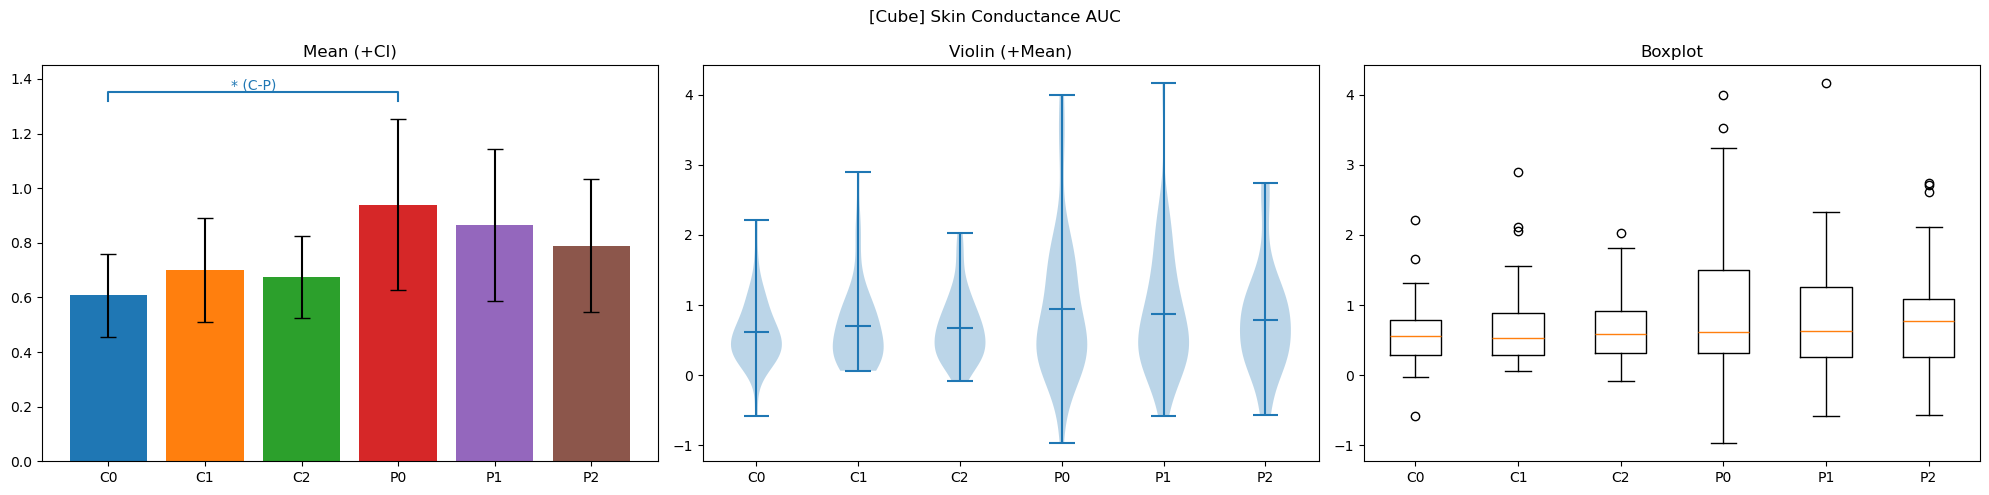

------ [Shovel] Skin Conductance AUC: ------
[Shovel] C0 subject 11_SePe is outlier
[Shovel] C1 subject 40_HeSe is outlier
[Shovel] C2 subject 11_SePe is outlier
[Shovel] P2 subject 11_SePe is outlier
[Shovel] dropping subject 40_HeSe
[Shovel] dropping subject 11_SePe


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,54.980905,1,39,54.980905,49.393095,1.961506e-08,1.961506e-08,0.217146,1.000000,✅
1,Scaling,0.163232,2,78,0.081616,0.342470,7.110764e-01,6.956090e-01,0.000823,0.930038,❌
2,Device * Scaling,0.491819,2,78,0.245909,0.760277,4.709697e-01,4.568938e-01,0.002475,0.887299,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-7.028022,39.0,two-sided,1.961506e-08,NaN,NaN,6.805e+05,-1.167092,✅


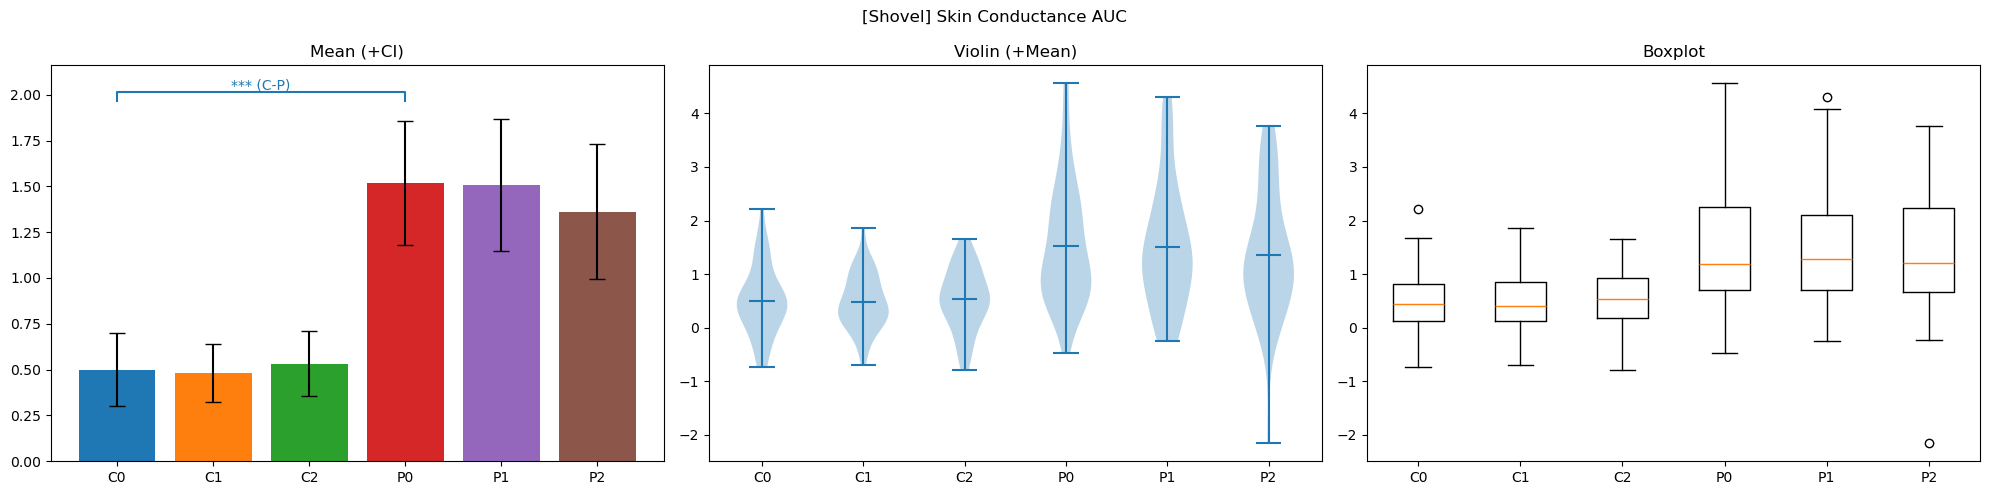

In [260]:
def gsr_con_auc(p):
    return normalized_auc(p, gsr_con_key)

title = 'Skin Conductance AUC'
ylabel = ''
report_exeriment(data, gsr_con_auc, cube, title, ylabel)
report_exeriment(data, gsr_con_auc, shovel, title, ylabel)

------ [Cube] Task Duration: ------
[Cube] C0 subject 1_AlDe is outlier
[Cube] C1 subject 26_BaBa is outlier
[Cube] dropping subject 1_AlDe
[Cube] dropping subject 26_BaBa


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,325.904112,1,39,325.904112,6.293008,0.016389,0.016389,0.019905,1.000000,✅
1,Scaling,449.749562,2,78,224.874781,4.622485,0.012671,0.022285,0.027263,0.742026,✅
2,Device * Scaling,34.950647,2,78,17.475324,0.426314,0.654423,0.602503,0.002173,0.770264,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.508587,39.0,two-sided,0.016389,NaN,NaN,2.681,-0.371038,✅
3,Scaling,-,1,2,True,True,-3.236727,39.0,two-sided,0.002469,0.007406,holm,13.723,-0.446663,✅


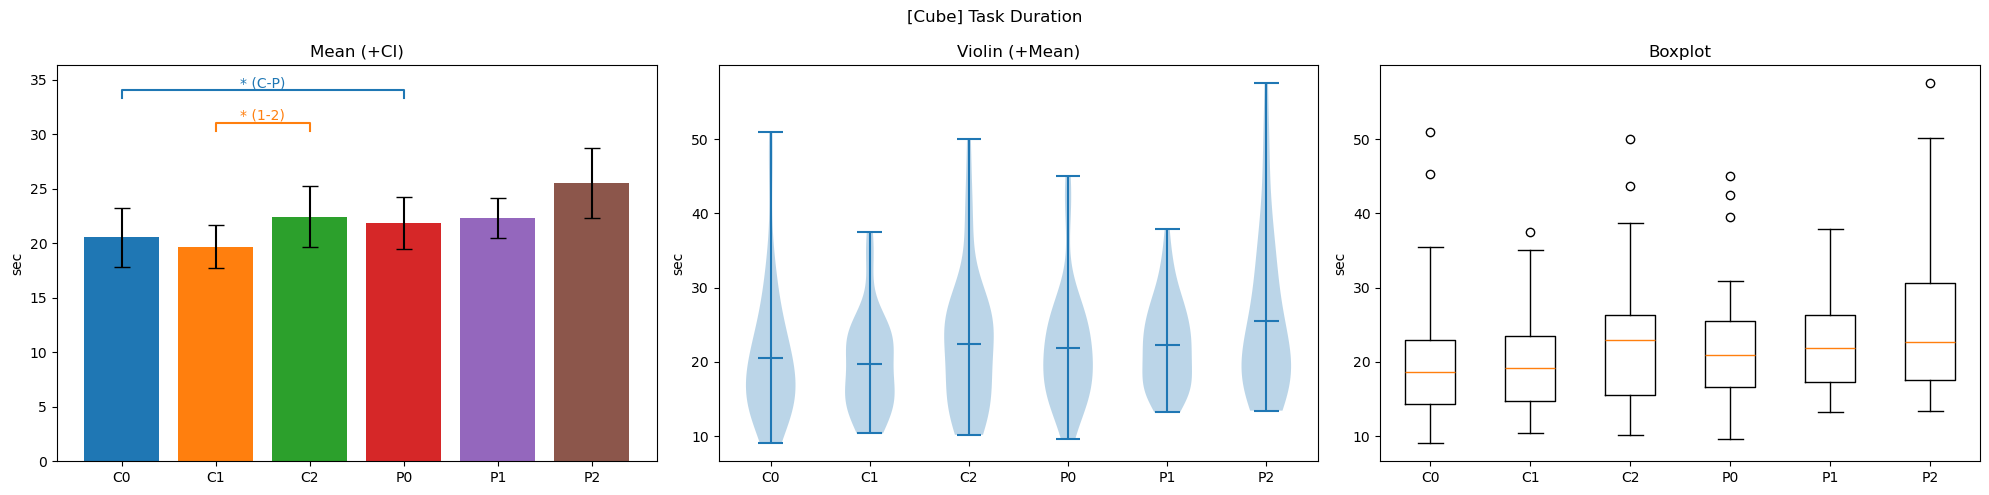

------ [Shovel] Task Duration: ------
[Shovel] C1 subject 2_ReDo is outlier
[Shovel] C2 subject 22_ClSt is outlier
[Shovel] dropping subject 2_ReDo
[Shovel] dropping subject 22_ClSt


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,19.036724,1,39,19.036724,0.128765,7.216509e-01,7.216509e-01,0.000300,1.000000,❌
1,Scaling,6468.766763,2,78,3234.383381,23.845035,8.297583e-09,7.694285e-07,0.092465,0.704556,✅
2,Device * Scaling,92.095102,2,78,46.047551,0.448213,6.404033e-01,6.027746e-01,0.001448,0.823930,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.794107,39.0,two-sided,0.008028,0.008028,holm,4.921,-0.260100,✅
2,Scaling,-,0,2,True,True,-5.287703,39.0,two-sided,0.000005,0.000015,holm,3790.168,-0.817877,✅
3,Scaling,-,1,2,True,True,-5.101965,39.0,two-sided,0.000009,0.000018,holm,2197.776,-0.593885,✅
5,Device * Scaling,C,0,2,True,True,-4.255644,39.0,two-sided,0.000127,0.000633,holm,196.26,-0.790754,✅
6,Device * Scaling,C,1,2,True,True,-3.808937,39.0,two-sided,0.000483,0.001931,holm,58.568,-0.626862,✅
7,Device * Scaling,P,0,1,True,True,-2.889714,39.0,two-sided,0.006267,0.015057,holm,6.091,-0.268359,✅
8,Device * Scaling,P,0,2,True,True,-4.492997,39.0,two-sided,0.000061,0.000367,holm,381.112,-0.683617,✅
9,Device * Scaling,P,1,2,True,True,-2.974188,39.0,two-sided,0.005019,0.015057,holm,7.383,-0.412713,✅


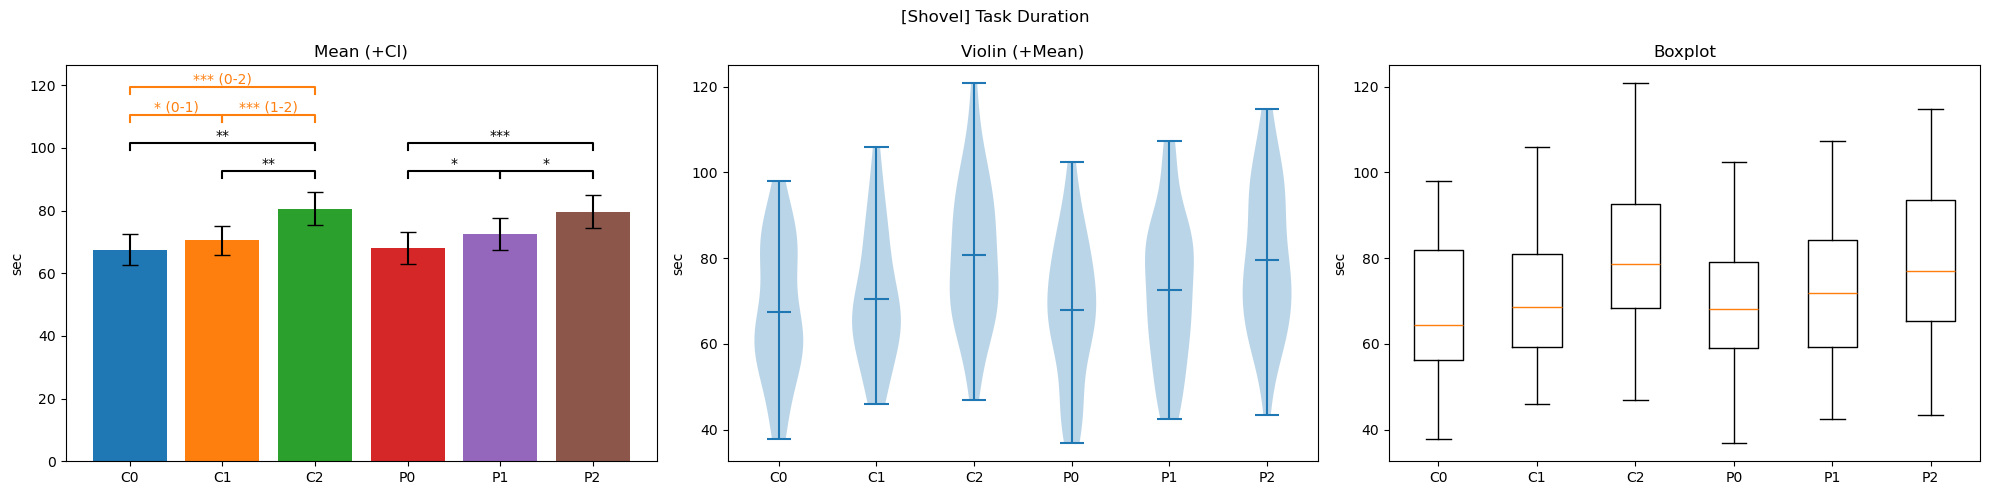

In [261]:
def task_duration(p):
    return (p[end_ts] - p[start_ts]) / 1_000

title = 'Task Duration'
ylabel = 'sec'
report_exeriment(data, task_duration, cube, title, ylabel)
report_exeriment(data, task_duration, shovel, title, ylabel)

------ [Cube] Head Travel Path Distance: ------
[Cube] C0 subject 25_LeSc is outlier
[Cube] C1 subject 13_FaPu is outlier
[Cube] C2 subject 13_FaPu is outlier
[Cube] P2 subject 32_AnRa is outlier
[Cube] dropping subject 32_AnRa
[Cube] dropping subject 13_FaPu
[Cube] dropping subject 25_LeSc


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,44.777252,1,38,44.777252,6.667318,0.013799,0.013799,0.024454,1.000000,✅
1,Scaling,74.670617,2,76,37.335309,5.085650,0.008455,0.019704,0.040125,0.665643,✅
2,Device * Scaling,0.759207,2,76,0.379603,0.089306,0.914662,0.894287,0.000425,0.888098,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.582115,38.0,two-sided,0.013799,NaN,NaN,3.129,-0.434712,✅
2,Scaling,-,0,2,True,True,-2.315241,38.0,two-sided,0.026096,0.052193,holm,1.836,-0.501991,🟨
3,Scaling,-,1,2,True,True,-2.556148,38.0,two-sided,0.014705,0.044115,holm,2.966,-0.462337,✅


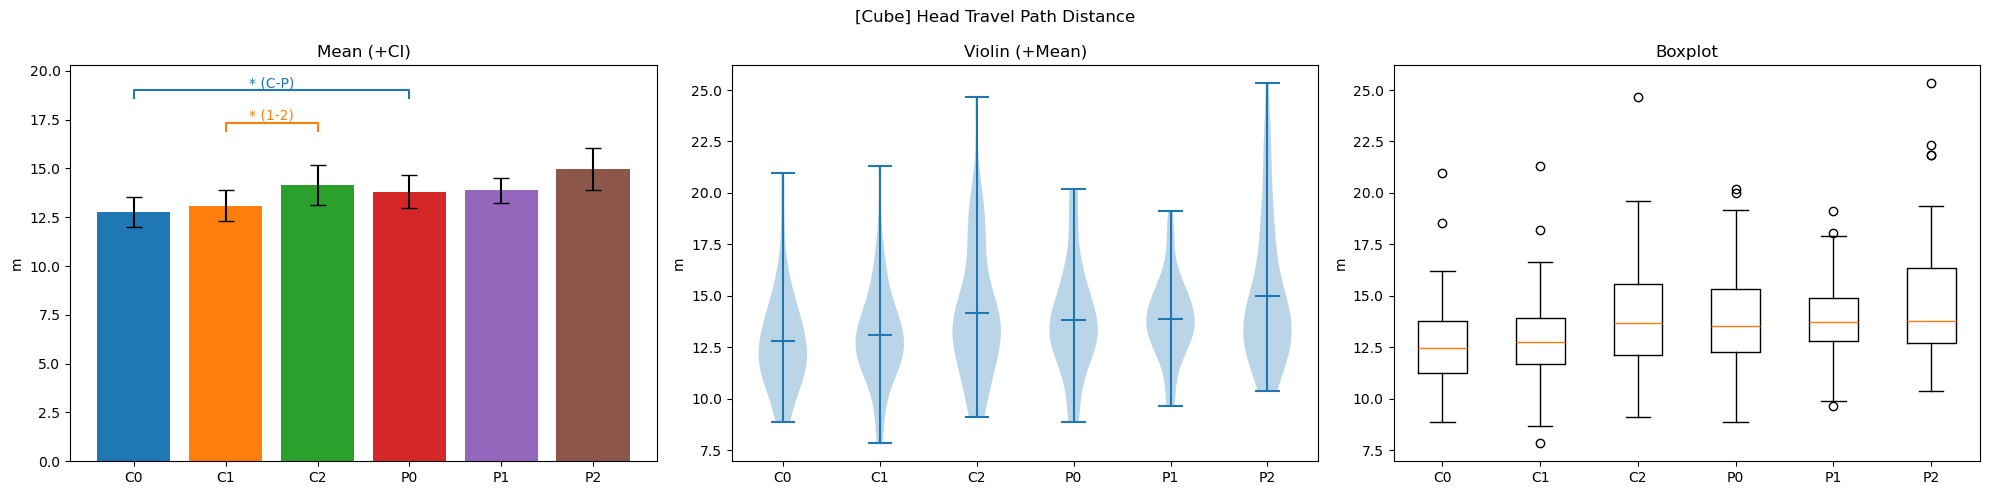

------ [Shovel] Head Travel Path Distance: ------
[Shovel] P1 subject 7_KlMe is outlier
[Shovel] P2 subject 7_KlMe is outlier
[Shovel] dropping subject 7_KlMe


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,144.784930,1,40,144.784930,4.657603,0.036974,0.036974,0.006481,1.000000,✅
1,Scaling,915.834554,2,80,457.917277,12.386346,0.000021,0.000091,0.039629,0.812074,✅
2,Device * Scaling,74.277797,2,80,37.138899,1.251898,0.291502,0.286243,0.003335,0.782694,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.158148,40.0,two-sided,0.036974,NaN,NaN,1.352,-0.181321,✅
1,Scaling,-,0,1,True,True,-2.580661,40.0,two-sided,0.013636,0.013636,holm,3.104,-0.243385,✅
2,Scaling,-,0,2,True,True,-4.086445,40.0,two-sided,0.000205,0.000614,holm,126.043,-0.522822,✅
3,Scaling,-,1,2,True,True,-3.132311,40.0,two-sided,0.003239,0.006478,holm,10.726,-0.293360,✅
5,Device * Scaling,C,0,2,True,True,-4.104569,40.0,two-sided,0.000194,0.001163,holm,132.483,-0.578359,✅
6,Device * Scaling,C,1,2,True,True,-2.747769,40.0,two-sided,0.008956,0.044779,holm,4.442,-0.368439,✅
7,Device * Scaling,P,0,1,True,True,-2.485582,40.0,two-sided,0.017213,0.054981,holm,2.55,-0.228531,🟨
8,Device * Scaling,P,0,2,True,True,-2.577442,40.0,two-sided,0.013745,0.054981,holm,3.083,-0.382008,🟨


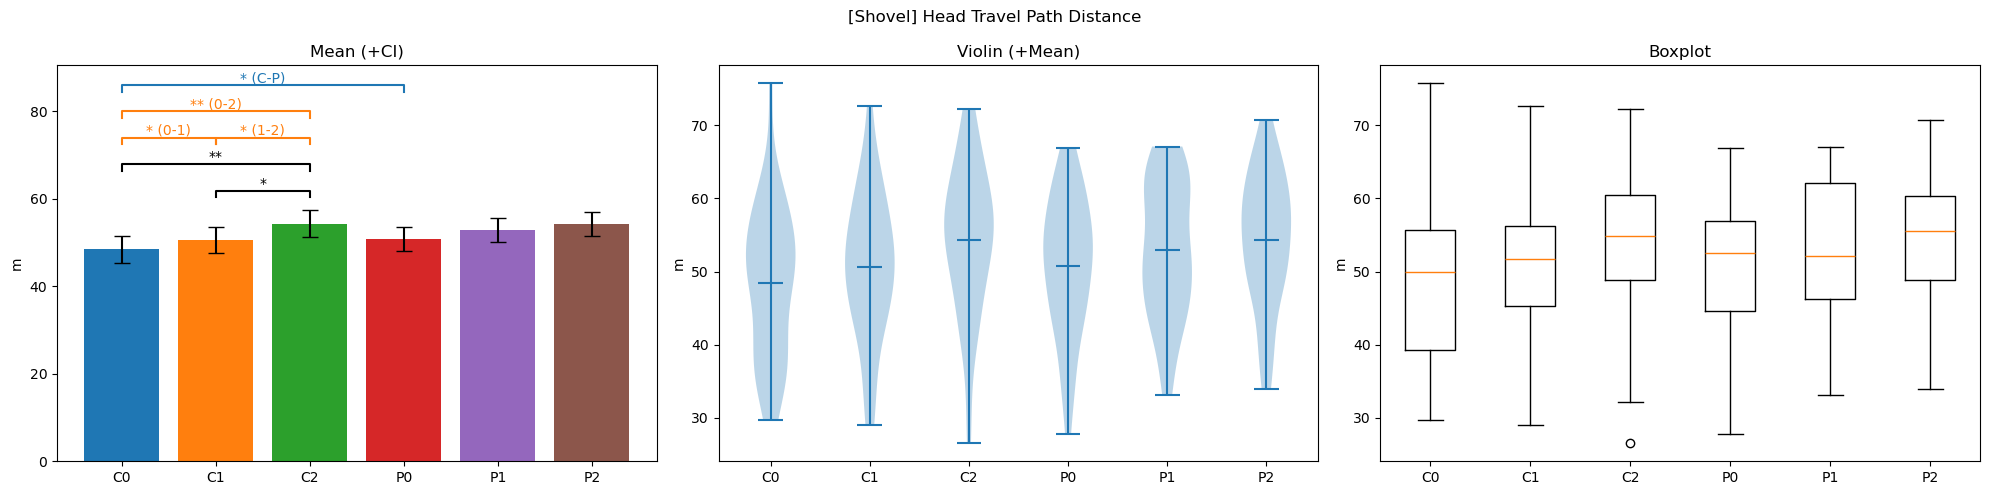

In [262]:
hmd = "hmd"

def single_pos_path_len(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    df[pt + "_x_delta"] = df[pt + "_x"].diff()
    df[pt + "_y_delta"] = df[pt + "_y"].diff()
    df[pt + "_z_delta"] = df[pt + "_z"].diff()

    df = df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    df["delta_dist"] = df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)

    return df["delta_dist"].sum()

def hmd_path_len_m(p):
    return single_pos_path_len(p, hmd)

title = 'Head Travel Path Distance'
ylabel = 'm'
report_exeriment(data, hmd_path_len_m, cube, title, ylabel)
report_exeriment(data, hmd_path_len_m, shovel, title, ylabel)

------ [Shovel] Average Hand Distance: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,144915.665754,1,41,144915.665754,21.445611,3.644724e-05,3.644724e-05,0.113962,1.000000,✅
1,Scaling,47863.699136,2,82,23931.849568,20.845784,4.790975e-08,2.046858e-07,0.040750,0.893294,✅
2,Device * Scaling,6456.889418,2,82,3228.444709,2.979550,5.634508e-02,6.436914e-02,0.005698,0.867399,🟨


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.630941,41.0,two-sided,0.000036,NaN,NaN,604.595,-0.767242,✅
1,Scaling,-,0,1,True,True,-4.349342,41.0,two-sided,0.000088,0.000177,holm,269.134,-0.382576,✅
2,Scaling,-,0,2,True,True,-5.505388,41.0,two-sided,0.000002,0.000007,holm,8170.08,-0.595064,✅
3,Scaling,-,1,2,True,True,-2.550874,41.0,two-sided,0.014575,0.014575,holm,2.908,-0.207796,✅
4,Device * Scaling,C,0,1,True,True,-3.926408,41.0,two-sided,0.000323,0.001615,holm,82.948,-0.303145,✅
5,Device * Scaling,C,0,2,True,True,-4.656015,41.0,two-sided,0.000034,0.000202,holm,650.323,-0.573021,✅
6,Device * Scaling,C,1,2,True,True,-2.331042,41.0,two-sided,0.024748,0.049496,holm,1.865,-0.247085,✅
7,Device * Scaling,P,0,1,True,True,-2.867157,41.0,two-sided,0.006512,0.019535,holm,5.794,-0.347337,✅
8,Device * Scaling,P,0,2,True,True,-3.512352,41.0,two-sided,0.001096,0.004386,holm,27.716,-0.403223,✅


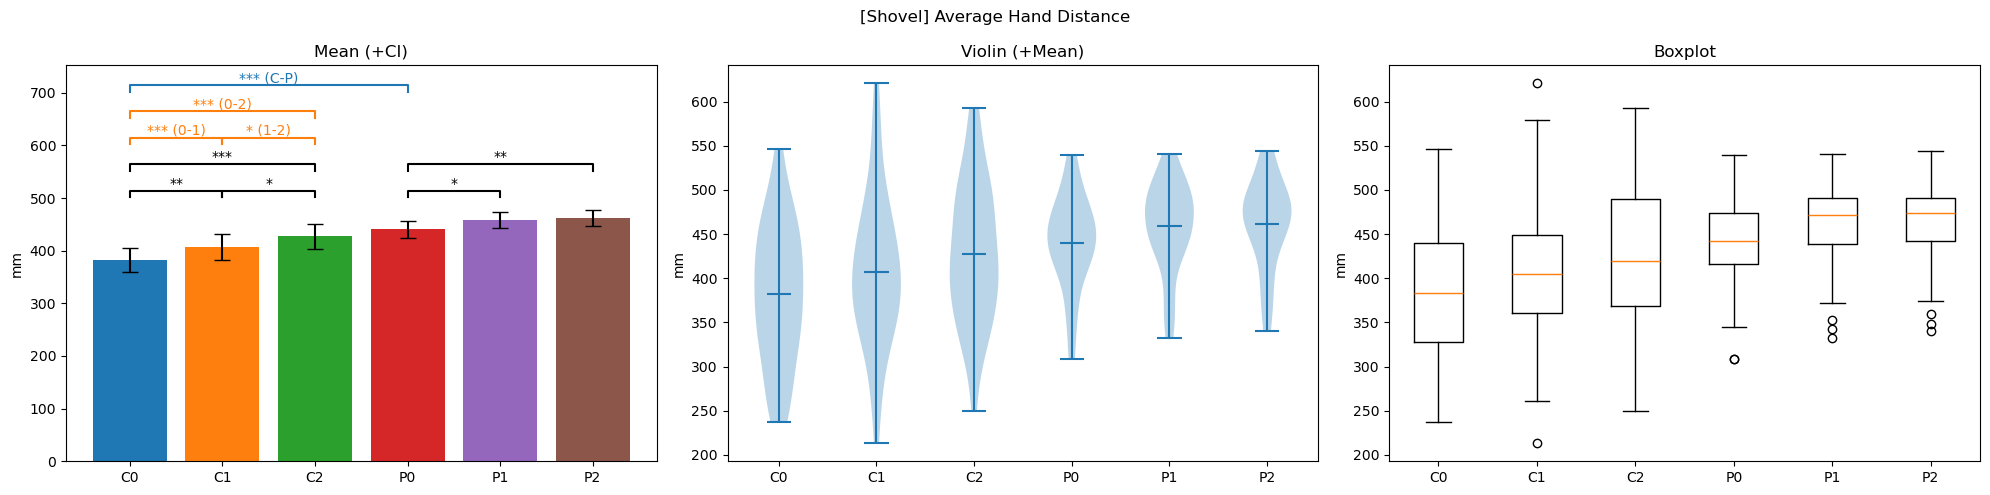

In [263]:
primary_tracked = "pt"
secondary_tracked = "st"
primary_visible = "pv"
secondary_visible = "sv"

def mean_pt_dist(p, pt_1, pt_2):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    df["dist"] = df.apply(lambda x: distance.euclidean((x[pt_1 + "_x"], x[pt_1 + "_y"], x[pt_1 + "_z"]), (x[pt_2 + "_x"], x[pt_2 + "_y"], x[pt_2 + "_z"])), axis = 1)
    return df["dist"].mean()

def tracked_hand_dist_mm(p):
    return mean_pt_dist(p, primary_tracked, secondary_tracked) * 1_000

title = "Average Hand Distance"
ylabel = "mm"
report_exeriment(data, tracked_hand_dist_mm, shovel, title, ylabel)

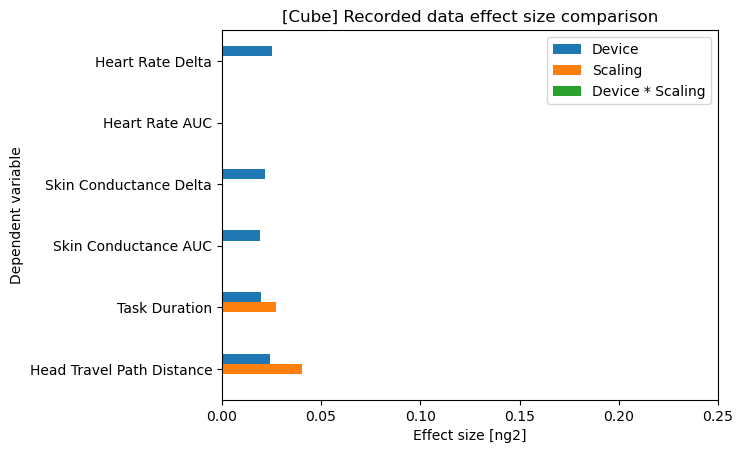

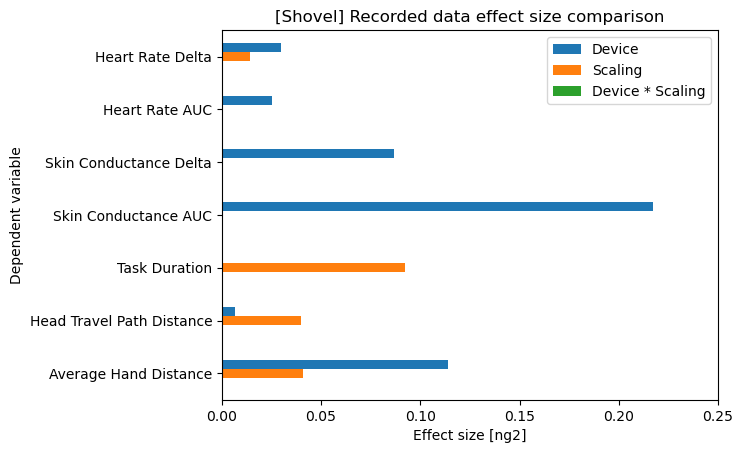

In [264]:
columns = [device_key, scaling_key, device_x_scaling_key]
eff_size_colors = ["tab:blue", "tab:orange", "tab:green"]

def get_aov_eff_sizes(df):
    eff_sizes = []
    for index, row in df.iterrows():
        if row[significance_key] == "✅":
            eff_sizes.append(row[eff_size_key])
        else:
            eff_sizes.append(0)
    return eff_sizes

cube_aov_index = list(map(lambda x: x[aovs_dv_key], cube_aovs))
cube_aov_values = list(map(lambda x: get_aov_eff_sizes(x[aovs_data_key]), cube_aovs))
cube_df = pd.DataFrame(cube_aov_values, columns=columns, index = cube_aov_index)
cube_df.plot(kind='barh', color=eff_size_colors)
plt.title("[Cube] Recorded data effect size comparison")
plt.xlabel("Effect size [" + eff_size_key + "]")
plt.ylabel("Dependent variable")
plt.xlim([0,0.25])
plt.gca().invert_yaxis()
plt.show()

shovel_aov_index = list(map(lambda x: x[aovs_dv_key], shovel_aovs))
shovel_aov_values = list(map(lambda x: get_aov_eff_sizes(x[aovs_data_key]), shovel_aovs))
shovel_df = pd.DataFrame(shovel_aov_values, columns=columns, index = shovel_aov_index)
shovel_df.plot(kind='barh', color=eff_size_colors)
plt.title("[Shovel] Recorded data effect size comparison")
plt.xlabel("Effect size [" + eff_size_key + "]")
plt.ylabel("Dependent variable")
plt.xlim([0,0.25])
plt.gca().invert_yaxis()
plt.show()

In [265]:
def normalized_curve(data, ax, e, c, key, ylim, ylabel):
    participants = list(map(lambda x: x[e][c], data))

    dfs = []
    for p in participants:
        start = p[start_ts]
        end = p[end_ts]
        duration_ms = end - start

        df = trim_df(p[imot], min_ts = start, max_ts = end)
        df = remove_timeseries_outliers(df, key)
        df["percentage"] = (df[unified_delta_key] / duration_ms) * 100
        df = df.set_index("percentage", drop = False)
        dfs.append(df)

    ax.title.set_text(c)
    ax.set_ylim(ylim)
    ax.set_xlabel('Task Duration [%]')
    ax.set_ylabel(ylabel)
    ax.set_xlim([0,100])

    sample_pts = list(map(lambda x: x, range(0, 101, 1)))
    synced_samples = []
    for i in sample_pts:
        sample_values = []
        for df in dfs:
            iloc_idx = df.index.get_indexer([i], method='nearest')
            nearest_row = df.iloc[iloc_idx[0]]
            nearest_value = nearest_row[key]
            sample_values.append(nearest_value)
        synced_samples.append(sample_values)

    #Individual
    for i in range(len(participants)):
        participant_values = list(map(lambda x: x[i], synced_samples))
        ax.plot(sample_pts, participant_values, color="tab:orange", alpha= 0.1, lw=3)

    #Trend
    agg_values = list(map(lambda x: [np.mean(x), get_confidence_interval(x)], synced_samples))
    y_mean = list(map(lambda x: x[0], agg_values))
    y_top = list(map(lambda x: x[0] + x[1], agg_values))
    y_bottom = list(map(lambda x: x[0] - x[1], agg_values))
    ax.plot(sample_pts, y_mean, color="tab:blue")
    ax.fill_between(sample_pts,y_bottom, y_top, color='tab:blue', alpha=0.3)

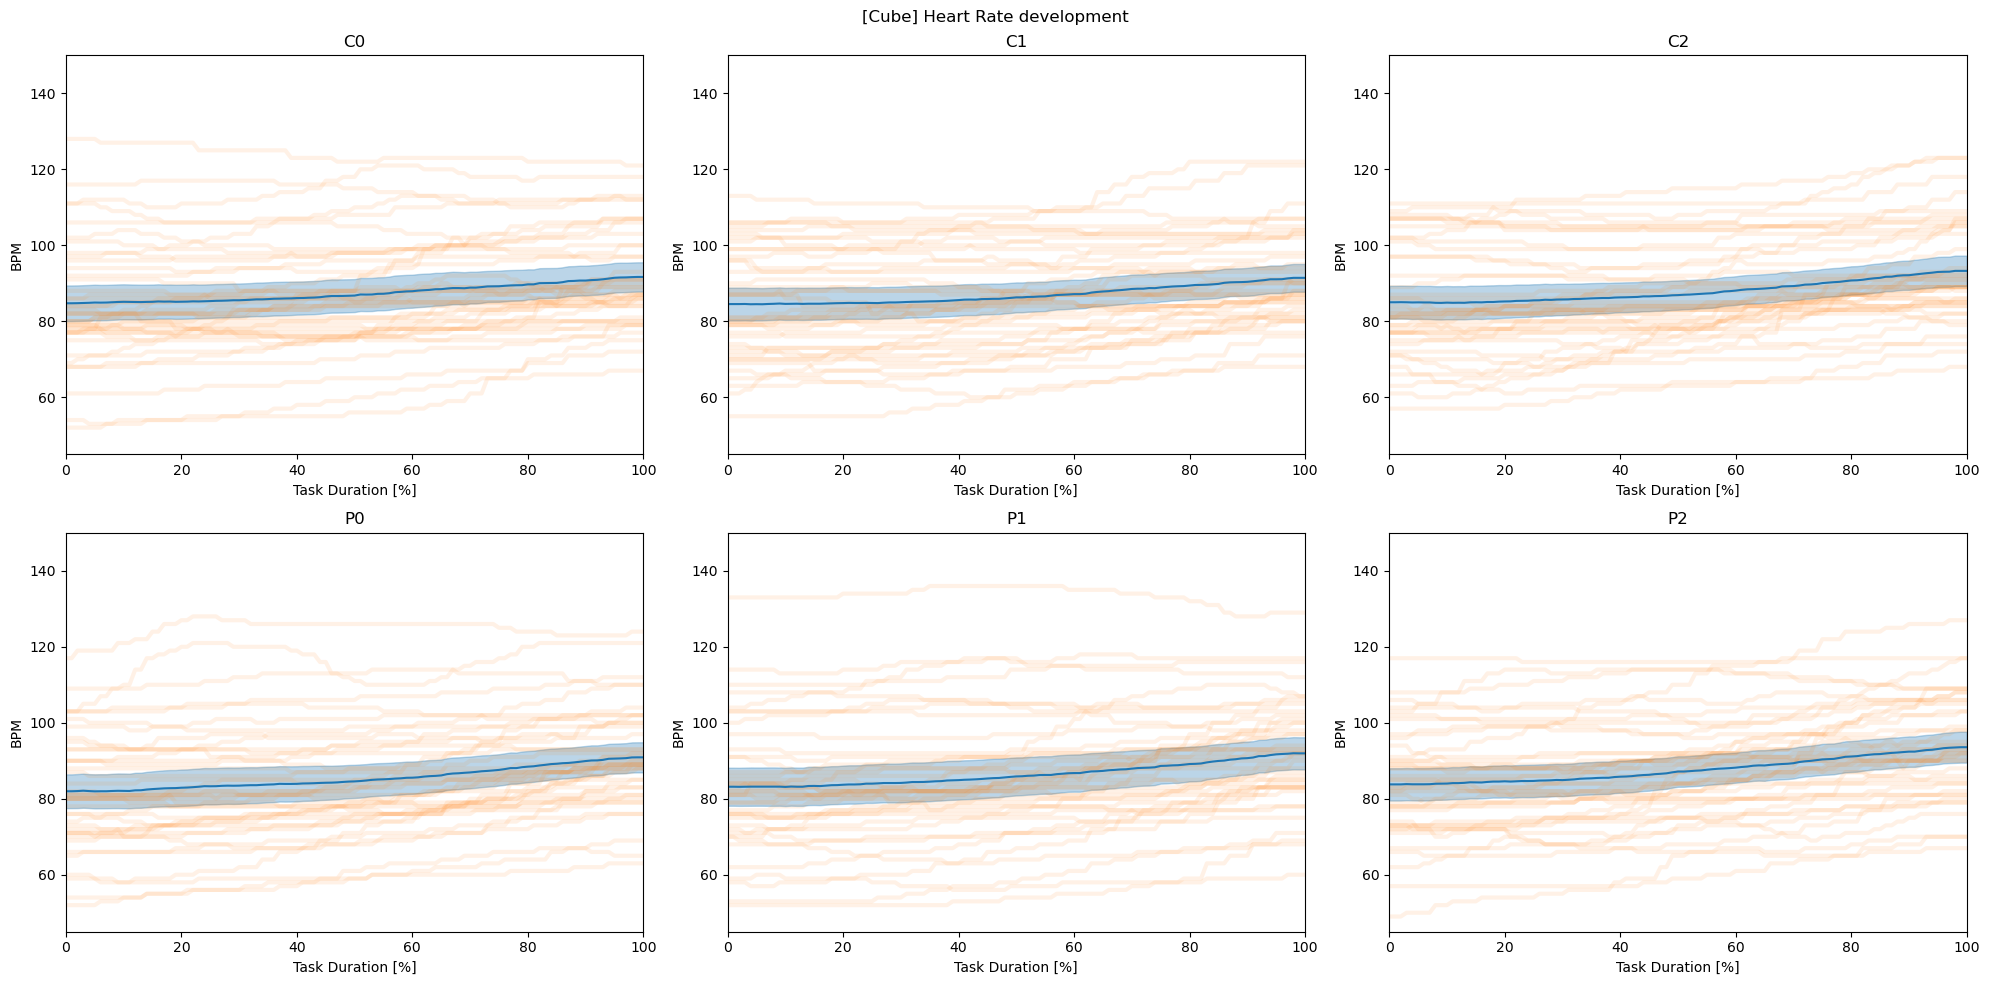

In [266]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [45,150]
ylabel = 'BPM'

plt.suptitle('[Cube] Heart Rate development')
normalized_curve(data, axs[0,0], cube, c_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,1], cube, c_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,2], cube, c_2, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,0], cube, p_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,1], cube, p_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,2], cube, p_2, hr_key, ylim, ylabel)

fig.tight_layout()
plt.show()

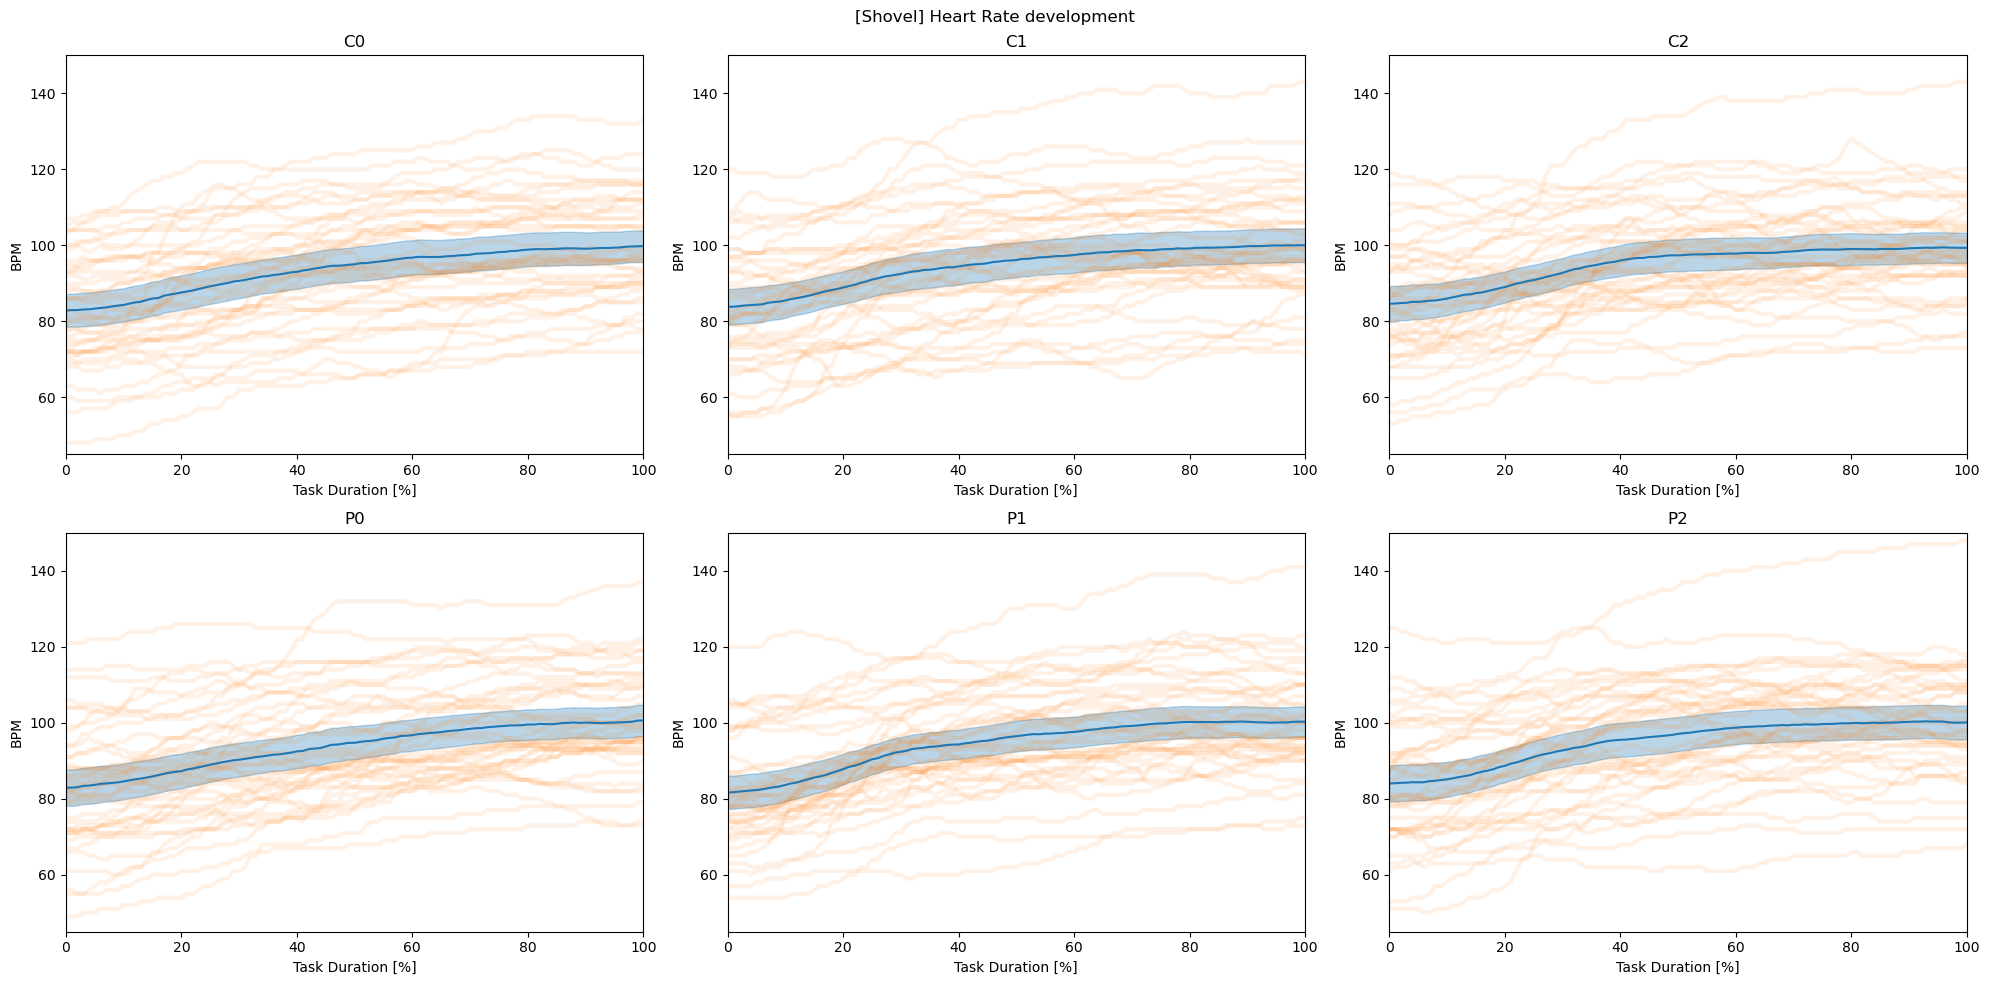

In [267]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [45,150]
ylabel = 'BPM'

plt.suptitle('[Shovel] Heart Rate development')
normalized_curve(data, axs[0,0], shovel, c_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,1], shovel, c_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,2], shovel, c_2, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,0], shovel, p_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,1], shovel, p_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,2], shovel, p_2, hr_key, ylim, ylabel)

fig.tight_layout()
plt.show()

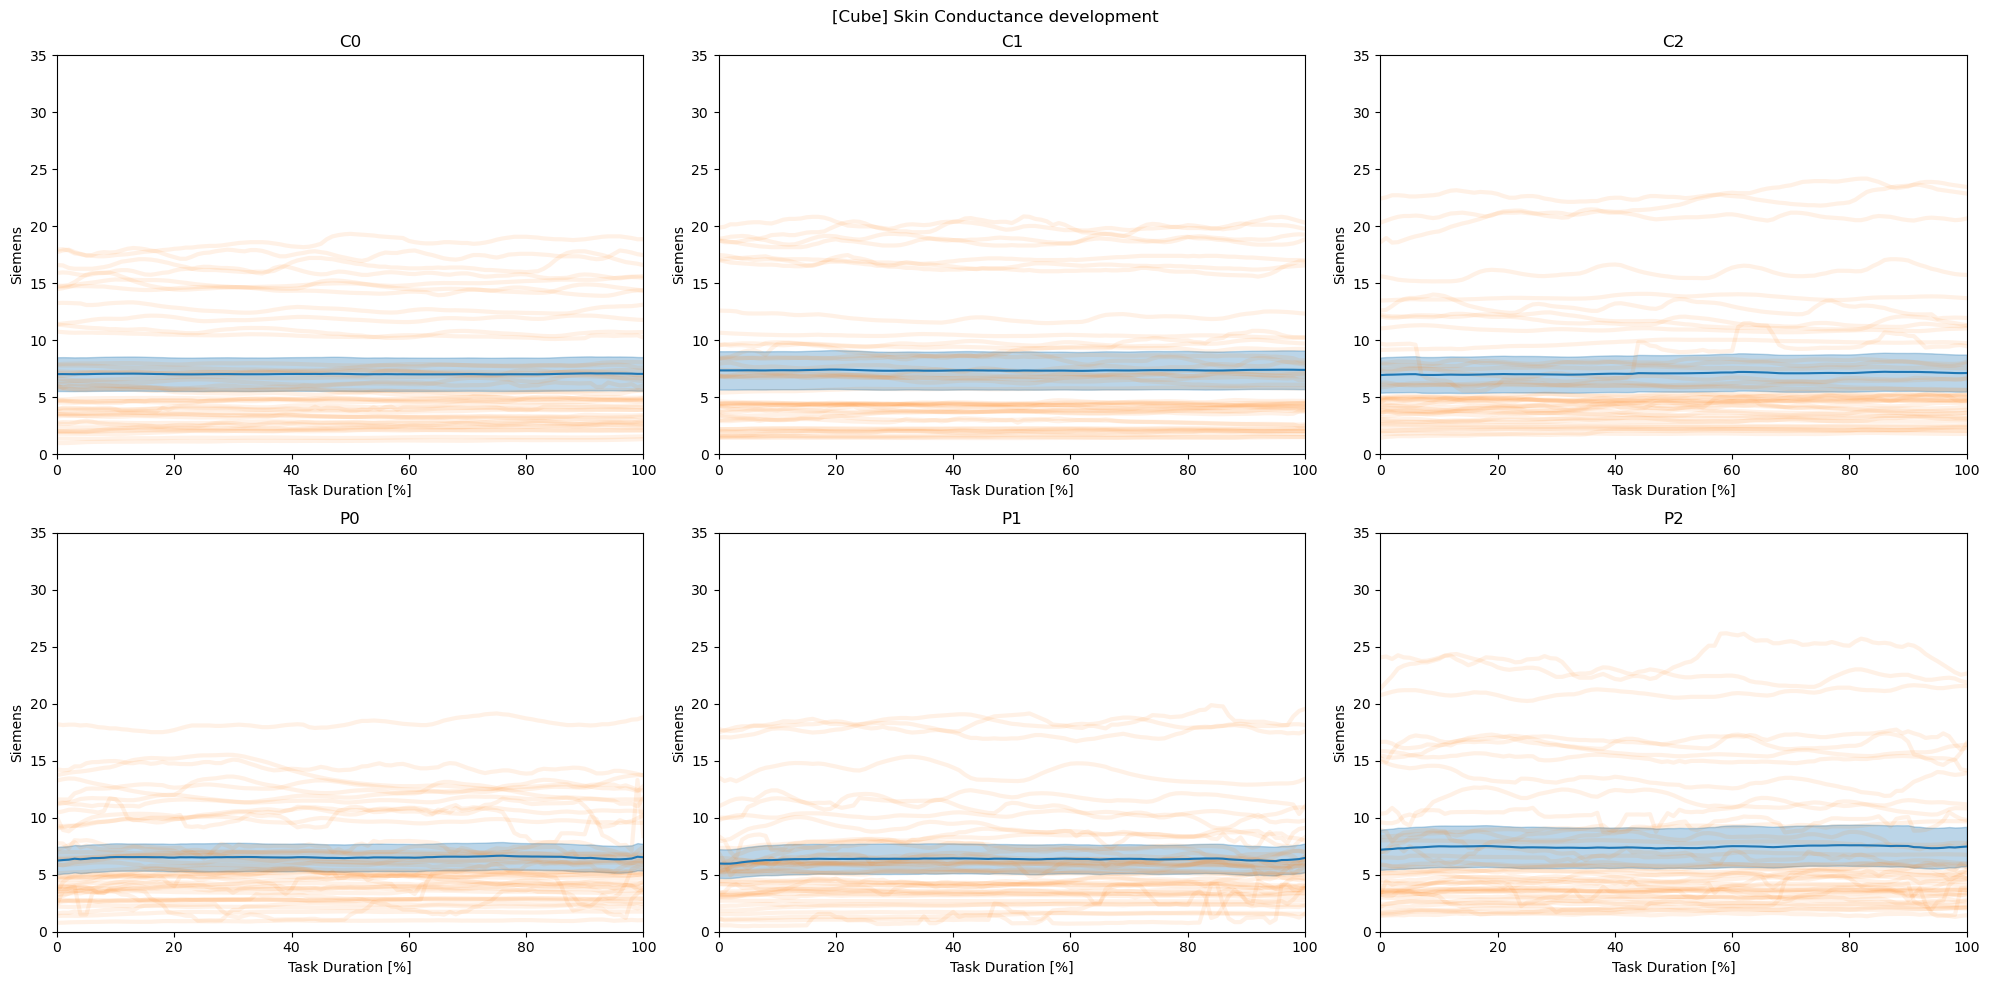

In [268]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [0,35]
ylabel = 'Siemens'

plt.suptitle('[Cube] Skin Conductance development')
normalized_curve(data, axs[0,0], cube, c_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,1], cube, c_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,2], cube, c_2, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,0], cube, p_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,1], cube, p_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,2], cube, p_2, gsr_con_key, ylim, ylabel)

fig.tight_layout()
plt.show()

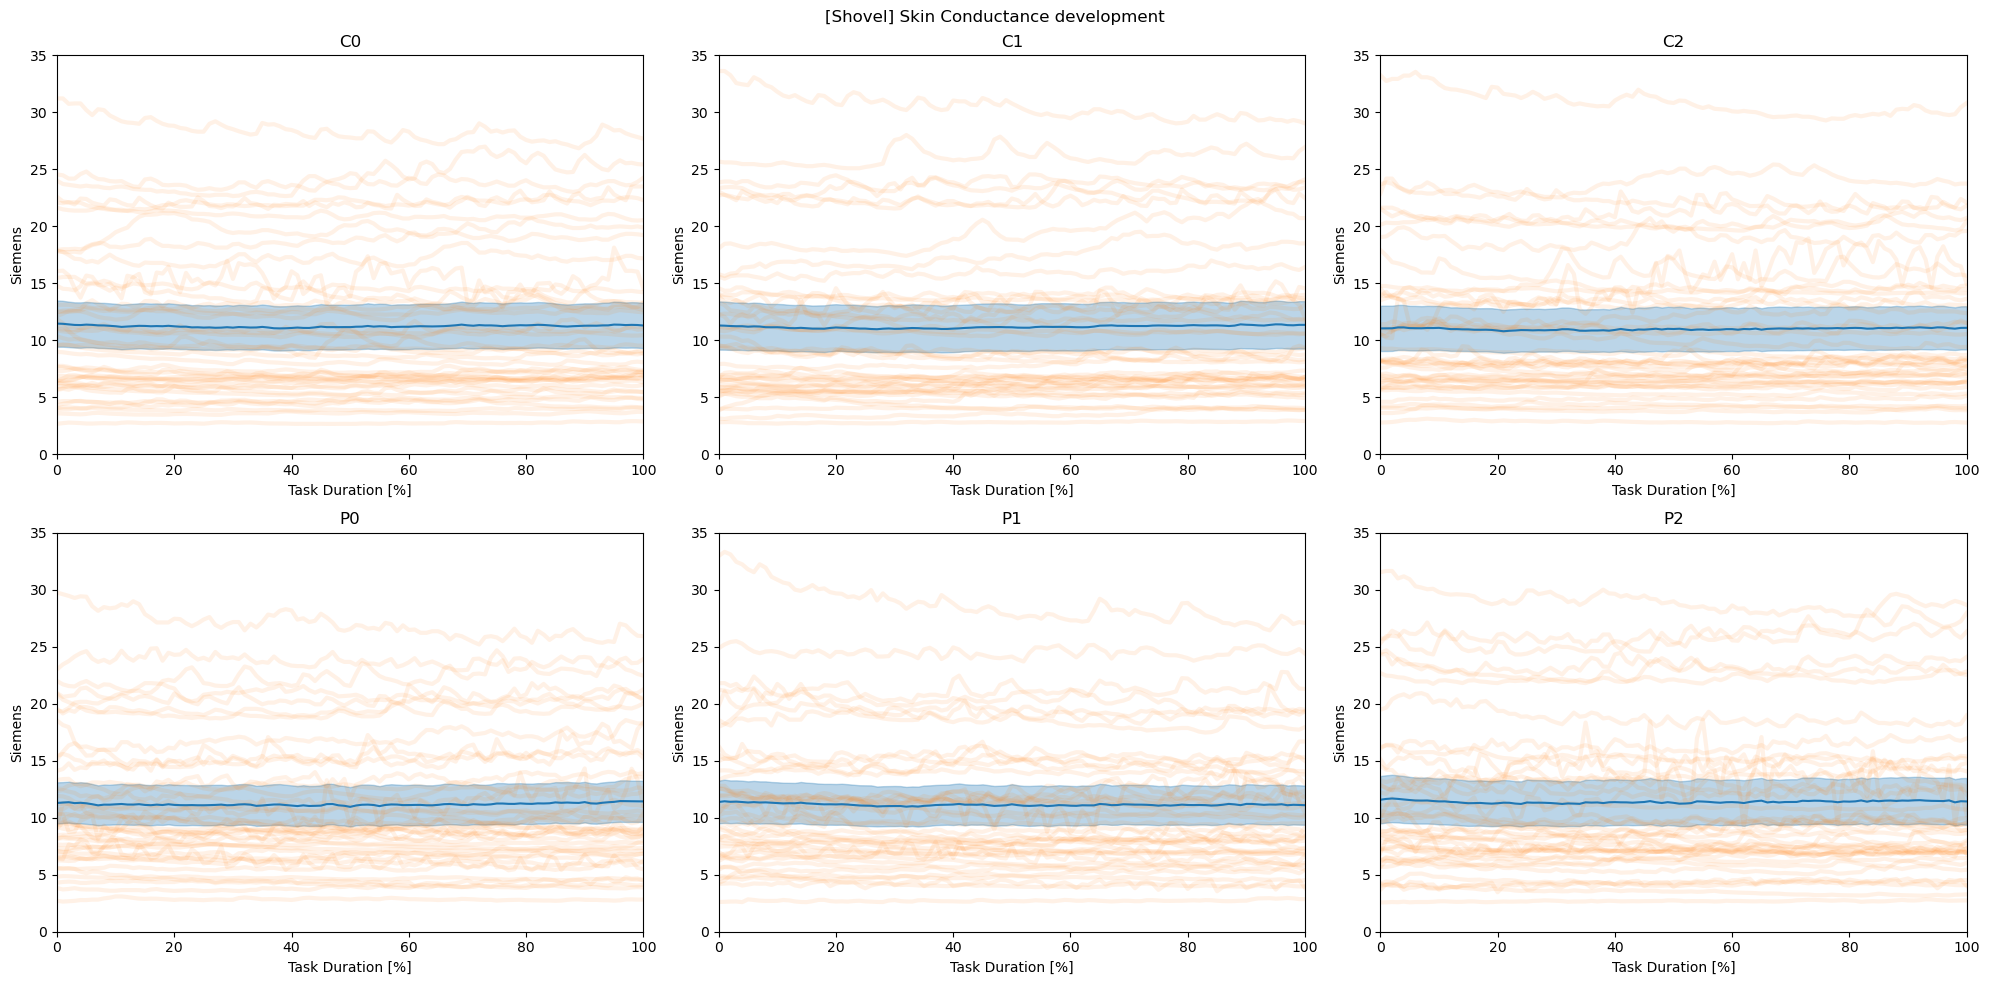

In [269]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [0,35]
ylabel = 'Siemens'

plt.suptitle('[Shovel] Skin Conductance development')
normalized_curve(data, axs[0,0], shovel, c_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,1], shovel, c_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,2], shovel, c_2, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,0], shovel, p_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,1], shovel, p_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,2], shovel, p_2, gsr_con_key, ylim, ylabel)

fig.tight_layout()
plt.show()

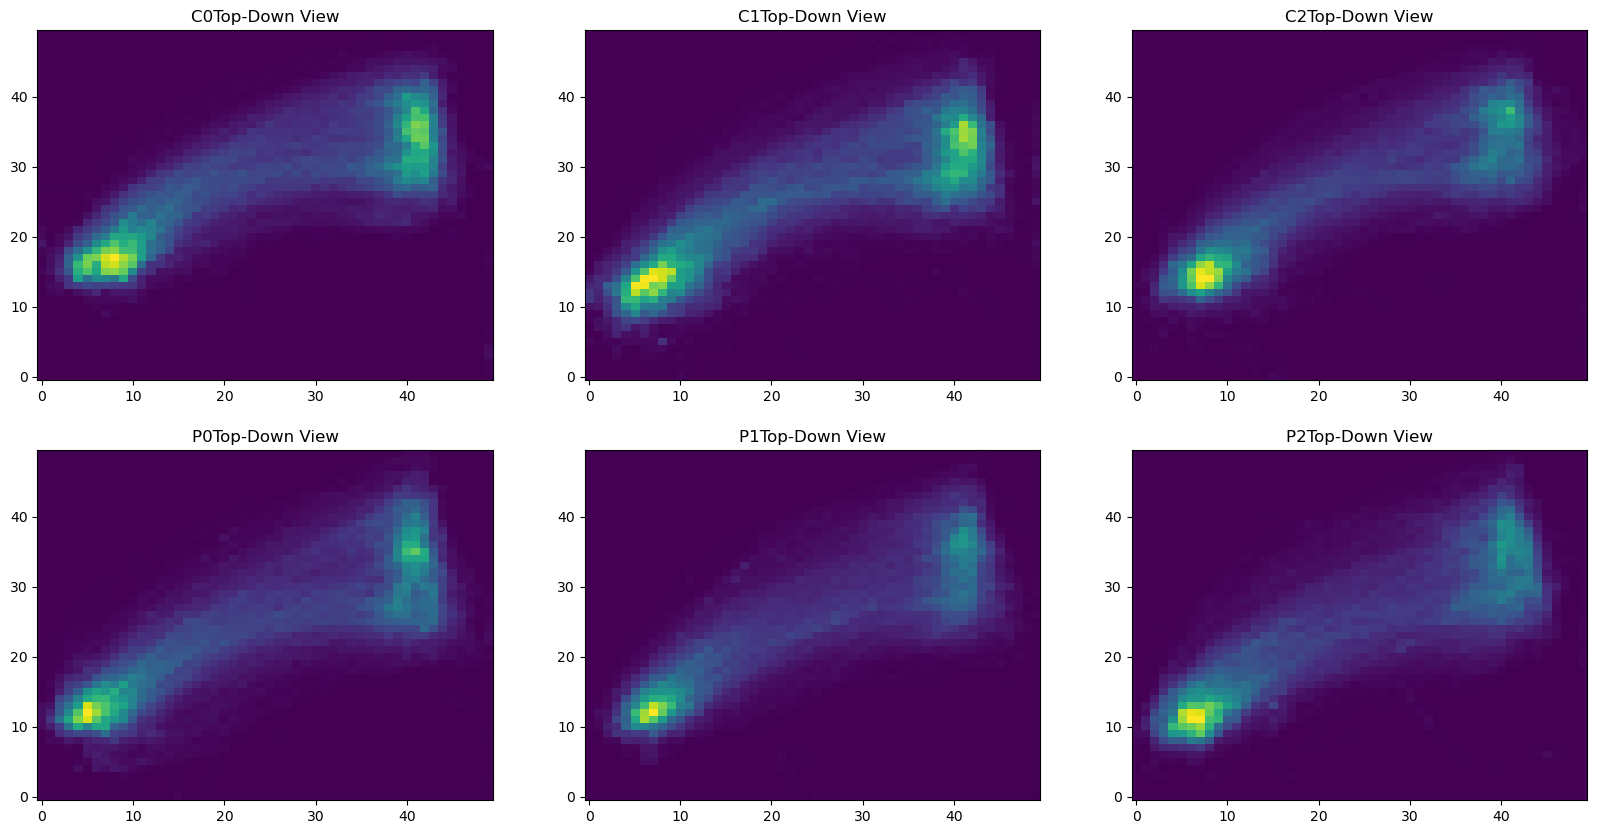

In [270]:
end_effector = 'ee'
primary_tracked = 'pt'
primary_visible = 'pv'
secondary_tracked = 'st'
secondary_visible = 'sv'
hmd = 'hmd'

tracking_pts = [end_effector, primary_tracked, primary_visible, secondary_tracked, secondary_visible, hmd]

def mirror_x(df, pt):
    key = pt + '_x'
    df[key] = df.apply(lambda x: -x[key] if x['primary_grab_hand'] == 'Left' else x[key], axis = 1)

def rectify_unity (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    for pt in tracking_pts:
        mirror_x(df, pt)

    return df

def top_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    max_x = 0.25
    min_x = -1.75

    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    forward = list(all_values[pt + "_z"])
    vertical = list(all_values[pt + "_y"])

    heatmap, xedges, yedges = np.histogram2d(lateral, forward, bins=50)

    ax.title.set_text(c + "Top-Down View")
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(20, 10))

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

top_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
top_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
top_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
top_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
top_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
top_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

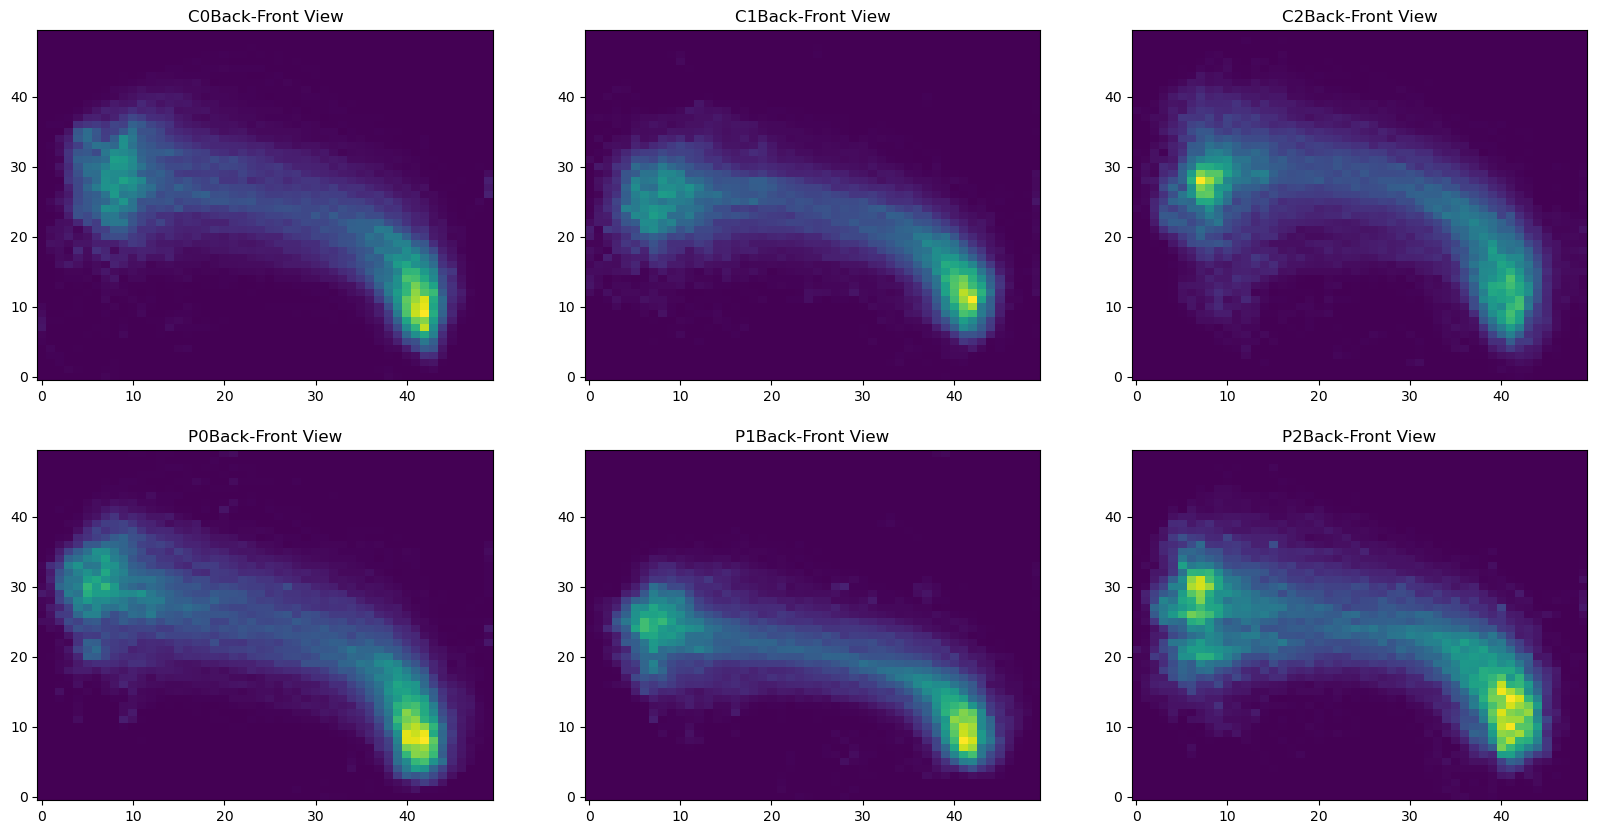

In [271]:
def front_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    max_x = 0.25
    min_x = -1.75

    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    forward = list(all_values[pt + "_z"])
    vertical = list(all_values[pt + "_y"])

    heatmap, xedges, yedges = np.histogram2d(lateral, vertical, bins=50)

    ax.title.set_text(c + "Back-Front View")
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(20, 10))

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

front_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
front_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
front_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
front_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
front_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
front_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

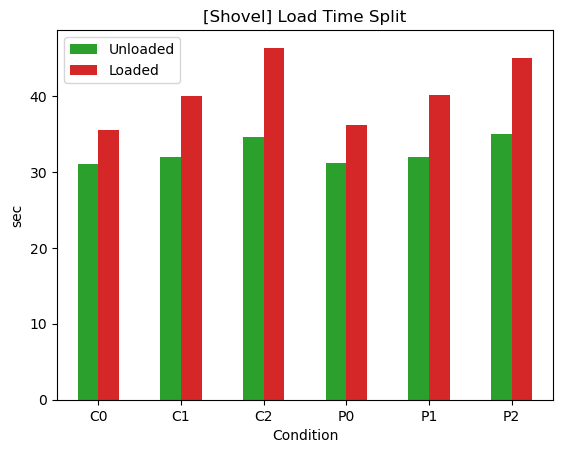

In [272]:
def single_load_time_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    loaded_time = 0
    unloaded_time = 0

    for i in range(20):
        single = df[(df["collision_or_load_count"] == i+1)]

        unloaded = single[(single["shovel_loaded_state"] == False)]
        unloaded_time += unloaded[unity_unix_key].max() - unloaded[unity_unix_key].min()

        loaded = single[(single["shovel_loaded_state"] == True)]
        loaded_time += loaded[unity_unix_key].max() - loaded[unity_unix_key].min()
    
    return [unloaded_time / 1_000, loaded_time / 1_000]

def agg_load_time_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    splits = list(map(lambda x: single_load_time_split(x), participants))
    
    unloaded_times = list(map(lambda x: x[0], splits))
    loaded_times = list(map(lambda x: x[1], splits))
    
    return [np.mean(unloaded_times), np.mean(loaded_times)]

condition_splits = list(map(lambda x: agg_load_time_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["Unloaded", "Loaded"], index = conditions)

df.plot(kind='bar', color=["tab:green", "tab:red"])

plt.title("[Shovel] Load Time Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

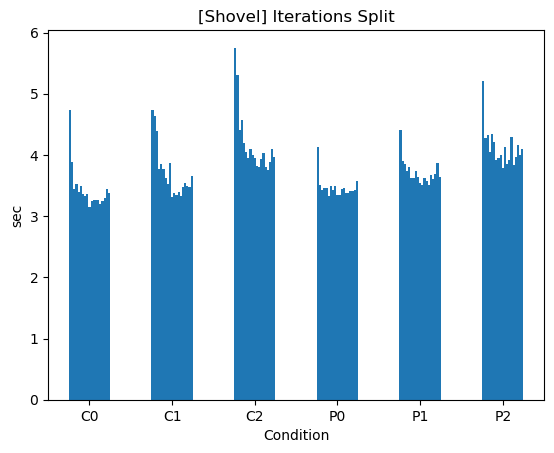

In [273]:
n_iterations = range(19)

def single_iteration_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    iteration_times = []

    for i in n_iterations:
        iteration = df[(df["collision_or_load_count"] == i+1)]
        time = (iteration[unity_unix_key].max() - iteration[unity_unix_key].min() ) / 1_000
        iteration_times.append(time)
    
    return iteration_times

def agg_iteration_split(data, c):
    participants = list(map(lambda x: x[shovel][c], data))

    participant_splits = list(map(lambda x: single_iteration_split(x), participants))
    n_participants = len(participants)

    splits = []

    for i in n_iterations:
        splits.append([])
        for j in range(n_participants):
            splits[i].append(participant_splits[j][i])

    split_means = list(map(lambda x: np.mean(x), splits))
    
    return split_means

condition_splits = list(map(lambda x: agg_iteration_split(data, x), conditions))

columns = list(map(lambda x: str(x+1), n_iterations))

df = pd.DataFrame(condition_splits, columns=columns, index = conditions)

df.plot(kind='bar', color = "tab:blue", legend=False)

plt.title("[Shovel] Iterations Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

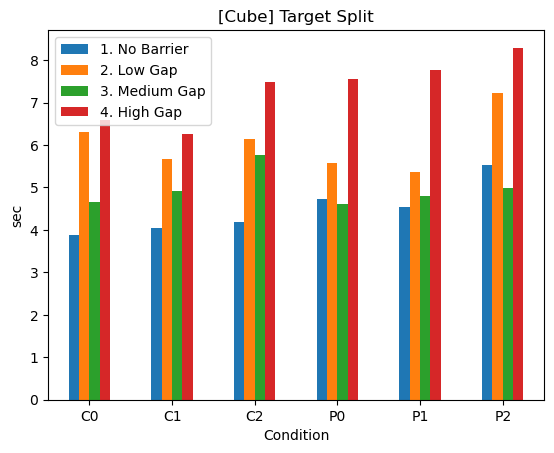

In [274]:
def single_target_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_time = first[unified_unix_key].max() - first[unified_unix_key].min()
    second_time = second[unified_unix_key].max() - second[unified_unix_key].min()
    third_time = third[unified_unix_key].max() - third[unified_unix_key].min()
    fourth_time = fourth[unified_unix_key].max() - fourth[unified_unix_key].min()

    return [first_time / 1_000, second_time / 1_000, third_time / 1_000, fourth_time / 1_000]

def agg_target_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_target_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.mean(first), np.mean(second), np.mean(third), np.mean(fourth)]

condition_splits = list(map(lambda x: agg_target_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Target Split")
plt.xlabel("Condition")
plt.ylabel("sec")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

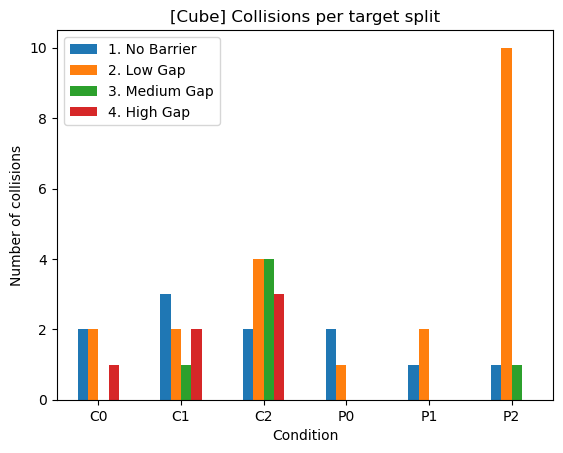

In [275]:
def single_collision_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_collisons =first["collision_or_load_count"].max() - first["collision_or_load_count"].min()
    second_collisons =second["collision_or_load_count"].max() - second["collision_or_load_count"].min()
    third_collisons =third["collision_or_load_count"].max() - third["collision_or_load_count"].min()
    fourth_collisons =fourth["collision_or_load_count"].max() - fourth["collision_or_load_count"].min()

    return [first_collisons, second_collisons, third_collisons, fourth_collisons]

def agg_collision_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_collision_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_collision_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Collisions per target split")
plt.xlabel("Condition")
plt.ylabel("Number of collisions")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

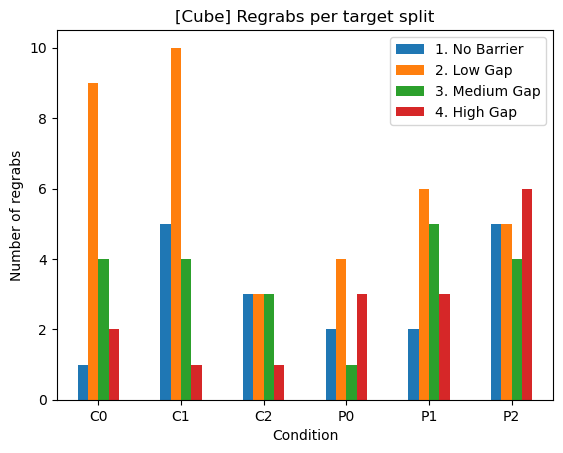

In [276]:
def single_grabcount_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_regrabs =first["grab_count"].max() - first["grab_count"].min()
    second_regrabs =second["grab_count"].max() - second["grab_count"].min()
    third_regrabs =third["grab_count"].max() - third["grab_count"].min()
    fourth_regrabs =fourth["grab_count"].max() - fourth["grab_count"].min()

    return [first_regrabs, second_regrabs, third_regrabs, fourth_regrabs]

def agg_grabcount_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_grabcount_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_grabcount_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Regrabs per target split")
plt.xlabel("Condition")
plt.ylabel("Number of regrabs")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

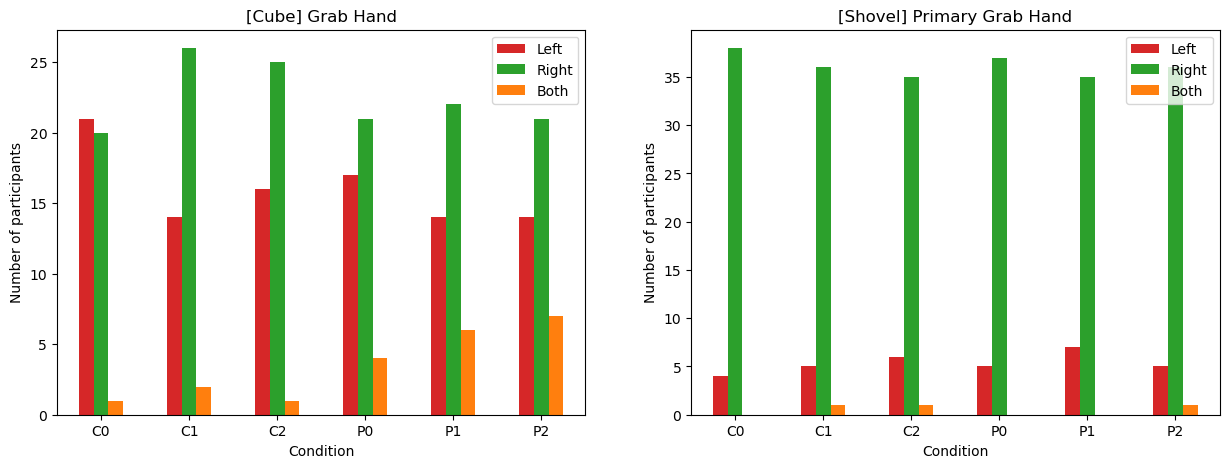

In [277]:
primary_left = "Left"
primary_right = "Right"
primary_both = "Both"
primary_none = "None"

primary_options = [primary_left, primary_right, primary_both]

def single_primary_hand(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    left = (df['primary_grab_hand'] == primary_left).any()
    right = (df['primary_grab_hand'] == primary_right).any()

    if left & right:
        return primary_both
    elif left:
        return primary_left
    elif right:
        return primary_right
    else:
        return primary_none

def agg_primary_hand(data, e, c):
    participants = list(map(lambda x: x[e][c], data))

    participant_hands = list(map(lambda x: single_primary_hand(x), participants))

    left = 0
    right = 0
    both = 0
    none = 0

    for i in range(len(participant_hands)):
        hands = participant_hands[i]

        if hands == primary_left:
            left += 1
        elif hands == primary_right:
            right += 1
        elif hands == primary_both:
            both += 1
        elif hands == primary_none:
            none += 1
    
    return [left, right, both]

cube_hands = list(map(lambda x: agg_primary_hand(data, cube, x), conditions))
cube_hands_df = pd.DataFrame(cube_hands, columns=primary_options, index = conditions)

shovel_hands = list(map(lambda x: agg_primary_hand(data, shovel, x), conditions))
shovel_hands_df = pd.DataFrame(shovel_hands, columns=primary_options, index = conditions)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cube_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[0])
axs[0].set_title('[Cube] Grab Hand')
axs[0].set_xlabel('Condition')
axs[0].set_ylabel('Number of participants')
axs[0].xaxis.set_tick_params(rotation=0)

shovel_hands_df.plot(kind='bar', color=["tab:red", "tab:green", "tab:orange"], ax=axs[1])
axs[1].set_title('[Shovel] Primary Grab Hand')
axs[1].set_xlabel('Condition')
axs[1].set_ylabel('Number of participants')
axs[1].xaxis.set_tick_params(rotation=0)

plt.show()

In [278]:
# Old GSR Resistance stuff (prefer conductance for reporting due to cleaner signal (and more significant results))

# def gsr_res_delta(p):
#     return pre_post_delta(p, gsr_res_key)

# title = 'GSR Resistance Delta'
# ylabel = 'Ohm'
# report_exeriment(data, gsr_res_delta, cube, title, ylabel)
# report_exeriment(data, gsr_res_delta, shovel, title, ylabel)

# def gsr_res_auc(p):
#     return normalized_auc(p, gsr_res_key)

# title = 'GSR Resistance AUC'
# ylabel = ''
# report_exeriment(data, gsr_res_auc, cube, title, ylabel)
# report_exeriment(data, gsr_res_auc, shovel, title, ylabel)

# fig, axs = plt.subplots(2, 3, figsize=(20, 10))
# ylim = [0,1000]
# ylabel = 'GSR Resistance [Ohm]'

# normalized_curve(data, axs[0,0], cube, c_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,1], cube, c_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,2], cube, c_2, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,0], cube, p_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,1], cube, p_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,2], cube, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(2, 3, figsize=(20, 10))
# ylim = [0,400]
# ylabel = 'GSR Resistance [Ohm]'

# normalized_curve(data, axs[0,0], shovel, c_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,1], shovel, c_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[0,2], shovel, c_2, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,0], shovel, p_0, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,1], shovel, p_1, gsr_res_key, ylim, ylabel)
# normalized_curve(data, axs[1,2], shovel, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

In [279]:
# Old sensor data viz

# def agg_curve(data, ax, e, c, key, ylim, ylabel):
#     participants = list(map(lambda x: x[e][c], data))
#     trimmmed_dfs = list(map(lambda x: trim_df(x[imot], min_ts = x[start_ts] - baseline_ms, max_ts = x[end_ts] + baseline_ms), participants))
#     dfs = list(map(lambda x: remove_timeseries_outliers(x, key).set_index(unified_delta_key, drop = False), trimmmed_dfs))

#     max_duration = 155 if e == shovel else 90

#     ax.title.set_text(c + " [" + e + "] ")
#     ax.set_xlim([-30,max_duration])
#     ax.set_ylim(ylim)
#     ax.set_xlabel('sec')
#     ax.set_ylabel(ylabel)

#     sample_pts_ms = list(map(lambda x: x * 1000, range(-30, max_duration, 1)))
#     synced_samples = []
#     for i in sample_pts_ms:
#         sample_values = []
#         for df in dfs:
#             iloc_idx = df.index.get_indexer([i], method='nearest')  # returns absolute index into df e.g. array([5])  
#             nearest_row = df.iloc[iloc_idx[0]]
#             nearest_ms = nearest_row[unified_delta_key]
#             nearest_value = nearest_row[key]
#             if abs(nearest_ms - i) < 1_000:
#                 sample_values.append(nearest_value)
#             else:
#                 sample_values.append(np.nan)
#         synced_samples.append(sample_values)

#     #Individual
#     x = list(map(lambda x: x / 1000, sample_pts_ms))
#     for i in range(len(participants)):
#         participant_values = list(map(lambda x: x[i], synced_samples))
#         ax.plot(x, participant_values, color="tab:orange", alpha= 0.1, lw=3)

#     #Trend
#     min_agg_count = 6
#     valid_samples = list(map(lambda x: list(filter(lambda y: not np.isnan(y), x)), synced_samples))
#     agg_values = list(map(lambda x: [np.mean(x) if len(x) >= min_agg_count else np.nan, 1.96 * np.std(x) / np.sqrt(len(x))if len(x) >= min_agg_count else np.nan], valid_samples))
#     y_mean = list(map(lambda x: x[0], agg_values))
#     y_top = list(map(lambda x: x[0] + x[1] * 0.5, agg_values))
#     y_bottom = list(map(lambda x: x[0] - x[1] * 0.5, agg_values))
#     ax.plot(x, y_mean, color="tab:blue")
#     ax.fill_between(x,y_bottom, y_top, color='tab:blue', alpha=0.3)

#     #VLines
#     durations = list(map(lambda x: (x[end_ts] - x[start_ts]) / 1_000, participants))
#     min_end = np.min(durations)
#     max_end = np.max(durations)
#     end_quantiles = np.quantile(durations, q = np.arange(0.25, 1, 0.25))
#     q_1 = end_quantiles[0]
#     median = end_quantiles[1]
#     q_3 = end_quantiles[2]
#     ax.axvline(x=0, color='green', label='Start')
#     ax.axvline(x=min_end, color='red', linestyle='--', alpha= 0.3)
#     ax.axvline(x=median, color='red')
#     ax.axvline(x=max_end, color='red', linestyle='--', alpha= 0.3)
#     ymin, ymax = ax.get_ylim()
#     rect = patches.Rectangle((q_1, ymin), q_3-q_1, ymax-ymin, facecolor='red')
#     rect.set_alpha(0.3)
#     ax.add_patch(rect)

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [40,160]
# ylabel = 'Heart Rate [BPM]'

# agg_curve(data, axs[0,0], shovel, c_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,0], shovel, c_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,0], shovel, c_2, hr_key, ylim, ylabel)
# agg_curve(data, axs[0,1], shovel, p_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,1], shovel, p_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,1], shovel, p_2, hr_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [40,160]
# ylabel = 'Heart Rate [BPM]'

# agg_curve(data, axs[0,0], cube, c_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,0], cube, c_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,0], cube, c_2, hr_key, ylim, ylabel)
# agg_curve(data, axs[0,1], cube, p_0, hr_key, ylim, ylabel)
# agg_curve(data, axs[1,1], cube, p_1, hr_key, ylim, ylabel)
# agg_curve(data, axs[2,1], cube, p_2, hr_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,2500]
# ylabel = 'GSR Resistance [Ohm]'

# agg_curve(data, axs[0,0], cube, c_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,0], cube, c_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,0], cube, c_2, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[0,1], cube, p_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,1], cube, p_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,1], cube, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,700]
# ylabel = 'GSR Resistance [Ohm]'

# agg_curve(data, axs[0,0], shovel, c_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,0], shovel, c_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,0], shovel, c_2, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[0,1], shovel, p_0, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[1,1], shovel, p_1, gsr_res_key, ylim, ylabel)
# agg_curve(data, axs[2,1], shovel, p_2, gsr_res_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,30]
# ylabel = 'GSR Conductance [Siemens]'

# agg_curve(data, axs[0,0], cube, c_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,0], cube, c_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,0], cube, c_2, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[0,1], cube, p_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,1], cube, p_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,1], cube, p_2, gsr_con_key, ylim, ylabel)

# plt.show()

# fig, axs = plt.subplots(3, 2, figsize=(15, 15))
# ylim = [0,40]
# ylabel = 'GSR Conductance [Siemens]'

# agg_curve(data, axs[0,0], shovel, c_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,0], shovel, c_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,0], shovel, c_2, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[0,1], shovel, p_0, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[1,1], shovel, p_1, gsr_con_key, ylim, ylabel)
# agg_curve(data, axs[2,1], shovel, p_2, gsr_con_key, ylim, ylabel)

# plt.show()

In [280]:
# Trajectory 3D Scatter viz

# def scatter_3D(data, fig, index, e, c, pt):
#     participants = list(map(lambda x: x[e][c], data))

#     dfs = list(map(lambda x: rectify_unity(x), participants))
#     all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

#     max_x = 0.25
#     min_x = -1.75

#     lateral = list(all_values[pt + "_x"])
#     forward = list(all_values[pt + "_z"])
#     vertical = list(all_values[pt + "_y"])

#     # Create a figure and 3D axis
#     # fig = plt.figure(figsize=(8,6))
#     # ax = fig.add_subplot(111, projection='3d')
#     ax = fig.add_subplot(1, 2, index, projection='3d')

#     ax.set_zlim(0, 1.5)
#     ax.set_xlim(-2, 0.5)
#     ax.set_ylim(-0.5, 2)

#     # Create scatter plot
#     ax.scatter3D(lateral, forward, vertical, color='tab:blue', alpha=0.01, s=0.5)



#     # Labels
#     ax.set_xlabel('Lateral')
#     ax.set_ylabel('Forward')
#     ax.set_zlabel('Vertical')
#     ax.set_title(c)


# fig = plt.figure(figsize=plt.figaspect(0.25))

# shovel_tip = 'ee'
# secondary_hand = 'st'
# primary_hand = 'pt'

# scatter_3D(data, fig, 1, shovel, c_0, shovel_tip)
# scatter_3D(data, fig, 2, shovel, c_1, shovel_tip)
# scatter_3D(data, fig, 3, shovel, c_2, shovel_tip)
# scatter_3D(data, fig, 4, shovel, p_0, shovel_tip)
# scatter_3D(data, fig, 5, shovel, p_1, shovel_tip)
# scatter_3D(data, fig, 6, shovel, p_2, shovel_tip)

# plt.show()


In [ ]:
#Old ttest-based significance bracket plotting logic

# def plot_significance_brackets(ax, scale, barheights, pairwise):
#     contrast = "Contrast"
#     p_corr = "p-corr"
#     p_unc = "p-unc"

#     significant_pairwise = get_significant_entries(pairwise)

#     n_bars = np.arange(len(conditions))

#     offset_step = (scale[1] - scale[0]) / 10
#     bracket_height = offset_step * 0.25
#     fixed_heights =  [np.max(barheights) + bracket_height*2] * len(conditions)

#     current_offset = 0

#     individual = significant_pairwise[significant_pairwise[contrast] == device_x_scaling_key]
#     individual_next = individual.loc[(individual['A'] != "0") | (individual['B'] != "2")]
#     if individual_next.shape[0] > 0:
#         for index, row in individual_next.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             if row[device_key] == "P":
#                 a += 3
#                 b += 3
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
#         current_offset += offset_step

#     individual_spanning = individual.loc[(individual['A'] == "0") & (individual['B'] == "2")]
#     if individual_spanning.shape[0] > 0:
#         for index, row in individual_spanning.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             if row[device_key] == "P":
#                 a += 3
#                 b += 3
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
#         current_offset += offset_step

#     scaling = significant_pairwise[significant_pairwise[contrast] == scaling_key]
#     scaling_next = scaling.loc[(scaling['A'] != "0") | (scaling['B'] != "2")]
#     if scaling_next.shape[0] > 0:
#         for index, row in scaling_next.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             text = row["A"] + "-" + row["B"]
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height, addtext=text, color="tab:orange")
#         current_offset += offset_step

#     scaling_spanning = scaling.loc[(scaling['A'] == "0") & (scaling['B'] == "2")]
#     if scaling_spanning.shape[0] > 0:
#         for index, row in scaling_spanning.iterrows():
#             a = int(row["A"])
#             b = int(row["B"])
#             text = row["A"] + "-" + row["B"]
#             barplot_annotate_brackets(ax, a, b, row[p_corr], n_bars, fixed_heights, offset= current_offset, height=bracket_height, addtext=text, color="tab:orange")
#         current_offset += offset_step


#     device = significant_pairwise[significant_pairwise[contrast] == device_key]
#     if device.shape[0] > 0:
#         for index, row in device.iterrows():
#             barplot_annotate_brackets(ax, 0, 3, row[p_unc], n_bars, fixed_heights, offset=current_offset, height=bracket_height, addtext="C-P", color="tab:blue")
#         current_offset += offset_step

#     # Set axis limits to provided scale or max bracket height if higher
#     ax.set_ylim([scale[0], np.max([fixed_heights[0]+current_offset, scale[1]])])